# GLM Tuning-Variable Analysis (PFC, mFC dataset)

Port of the LEC GLM analysis pipeline (`code/LEC_glm_tuning_variables.ipynb`) to
the mPFC dataset under `mFC_data/data/`. Same model, same plots, same variants
— with two differences:

1. **No head direction.** The mFC dataset has no `HD_raw` recording, so HD is
   dropped from every fit via `regressors_to_include`. 8 regressors instead of
   9; default-bin design matrix is 91 cols (127 − 36 HD).
2. **Disk-loaded data.** The mFC dataset is a directory of `.npy` files rather
   than a pickle. `build_data_dic_from_pfc(data_folder, recdays)` (defined in
   the PFC sibling module) constructs the same nested-dict shape that
   `run_glm_analysis` consumes.

The substantive analyses (F-test significance, CPD / R² / ΔR², joint time-any
and distance-any groups, raised-cosine variant, 20-bin GP column-matched
variant, reference-coded sanity check) are unchanged from the LEC notebook.

## Method: per-regressor significance via permutation F-test

For each neuron, we fit a per-neuron OLS GLM:

    y_t = X_t β + ε_t

`X` is the design matrix of one-hot encoded task variables. PFC variables:
place (21 bins), goal progress (10 equal-width bins), speed, acceleration,
time-since-reward, time-to-reward, distance-since-reward, distance-to-reward
(10 decile bins each). **HD is dropped** (no recording). Total: **91 cols**
at the default `gp_n_bins=10`, or 101 cols at `gp_n_bins=20`.

To test whether a regressor group (e.g., all 21 place columns) explains
firing-rate variance, we use the nested F-test against a permutation null
(circularly shifted firing rate). A neuron is "tuned" if its observed F
exceeds the 95th percentile of the 100-shift null.

CPD = (RSS_reduced − RSS_full)/RSS_reduced is reported per regressor as an
effect-size complement to the F-test.

In [24]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import os, sys
from tqdm import tqdm
from importlib import reload
from collections import defaultdict
import glm_analysis_v2
reload(glm_analysis_v2)

<module 'glm_analysis_v2' from '/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/code/glm_analysis_v2.py'>

In [25]:
DATA_FOLDER = '/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/data'
META = os.path.join(DATA_FOLDER, 'MetaData')

In [26]:
# Canonical recday list (25 double-day recordings, ABCD tasks only)
mouse_recdays = list(np.load(os.path.join(META, 'combined_ABCDonly_days.npy')))
mouse_recdays = [str(mr) for mr in mouse_recdays]
print(f'{len(mouse_recdays)} recdays in combined_ABCDonly_days.npy')
print('first 3:', mouse_recdays[:3])

25 recdays in combined_ABCDonly_days.npy
first 3: ['ab03_01092023_02092023', 'ab03_05092023_06092023', 'ab03_29082023_30082023']


In [27]:
# Memory note: eager-loading all 25 recdays uses ~3-5 GB of RAM. For a quick
# first pass, uncomment the next line to validate on a few recdays before
# expanding.
# mouse_recdays = mouse_recdays[:5]

from glm_analysis_v2 import build_data_dic_from_pfc
data_dic = build_data_dic_from_pfc(DATA_FOLDER, mouse_recdays)
mouse_recdays = sorted(data_dic.keys())   # in case any were skipped
print(f'\n{len(mouse_recdays)} recdays loaded')

  ab03_01092023_02092023: 7 sessions
  ab03_05092023_06092023: 8 sessions
  ab03_29082023_30082023: 9 sessions
  ah03_12082021_13082021: 8 sessions
  ah03_18082021_19082021: 8 sessions
  ah04_01122021_02122021: 8 sessions
  ah04_05122021_06122021: 8 sessions
  ah04_07122021_08122021: 8 sessions
  ah04_09122021_10122021: 8 sessions
  ah04_14122021_16122021: 8 sessions
  ah07_01092023_02092023: 7 sessions
  ah07_27082023_28082023: 7 sessions
  ah07_29082023_30082023: 7 sessions
  me08_06092021_09092021: 8 sessions
  me08_10092021_11092021: 6 sessions
  me08_12092021_13092021: 7 sessions
  me10_09122021_10122021: 9 sessions
  me10_14122021_15122021: 6 sessions
  me10_17122021_19122021: 8 sessions
  me10_20122021_21122021: 6 sessions
  me11_01122021_02122021: 8 sessions
  me11_05122021_06122021: 9 sessions
  me11_07122021_08122021: 8 sessions
  me11_09122021_10122021: 9 sessions
  me11_12122021_13122021: 9 sessions

25 recdays loaded


In [28]:
# 8 PFC regressors (HD dropped). Pass this list to every run_glm_analysis,
# compute_tuning_arrays, and plot_* call so the index maps match the design
# matrix throughout.
PFC_REGRESSORS = ['place', 'goal_progress', 'speed', 'acceleration',
                  'time_since_reward', 'time_to_reward',
                  'distance_since_reward', 'distance_to_reward']
print('PFC regressors:', PFC_REGRESSORS)

PFC regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_since_reward', 'time_to_reward', 'distance_since_reward', 'distance_to_reward']


In [30]:
# Save/load + light publication-style setup (gridmaze-plotter skill).
from importlib import reload
import glm_analysis_v2
reload(glm_analysis_v2)
from glm_analysis_v2 import (
    apply_gridmaze_style, save_section, run_or_load_glm, load_glm_results,
)
apply_gridmaze_style()

# Persistent per-region output directory; section-prefixed filenames inside.
SAVE_DIR = '../glm_outputs/PFC'
print(f'Will save GLM outputs to {SAVE_DIR}')

Will save GLM outputs to ../glm_outputs/PFC


## Baseline GLM fit + per-regressor tuning

In [35]:
reload(glm_analysis_v2)
from glm_analysis_v2 import (
    run_glm_analysis, compute_tuning_arrays, group_tuning_by_mouse,
    plot_tuning_piecharts_binary,
)

GLM_results, Permutation_results = run_or_load_glm(
    mouse_recdays, data_dic, SAVE_DIR, 'baseline',
    regressors_to_include=PFC_REGRESSORS,
)

run_or_load_glm('baseline'): no cache (or force_refit) — fitting


Processing recording days:   0%|          | 0/25 [00:00<?, ?it/s]


ab03_01092023_02092023


/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/code/glm_analysis_v2.py:881: RuntimeWarning: invalid value encountered in cast
  'speed':                Sp_enc,


  Design matrix: 26462 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


...


me11_09122021_10122021
  Design matrix: 27028 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  96%|█████████▌| 24/25 [22:13<00:34, 34.89s/it]


me11_12122021_13122021
  Design matrix: 24771 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days: 100%|██████████| 25/25 [22:26<00:00, 53.87s/it]

run_or_load_glm('baseline'): saved 2 pickle(s) to ../glm_outputs/PFC


ab03_01092023_02092023: tuning array shape = (63, 8)
ab03_05092023_06092023: tuning array shape = (64, 8)
ab03_29082023_30082023: tuning array shape = (70, 8)
ah03_12082021_13082021: tuning array shape = (16, 8)
ah03_18082021_19082021: tuning array shape = (15, 8)
ah04_01122021_02122021: tuning array shape = (117, 8)
ah04_05122021_06122021: tuning array shape = (114, 8)
ah04_07122021_08122021: tuning array shape = (81, 8)
ah04_09122021_10122021: tuning array shape = (99, 8)
ah04_14122021_16122021: tuning array shape = (70, 8)
ah07_01092023_02092023: tuning array shape = (97, 8)
ah07_27082023_28082023: tuning array shape = (80, 8)
ah07_29082023_30082023: tuning array shape = (72, 8)
me08_06092021_09092021: tuning array shape = (23, 8)
me08_10092021_11092021: tuning array shape = (32, 8)
me08_12092021_13092021: tuning array shape = (23, 8)
me10_09122021_10122021: tuning array shape = (28, 8)
me10_14122021_15122021: tuning array shape = (20, 8)
me10_17122021_19122021: tuning array shape =

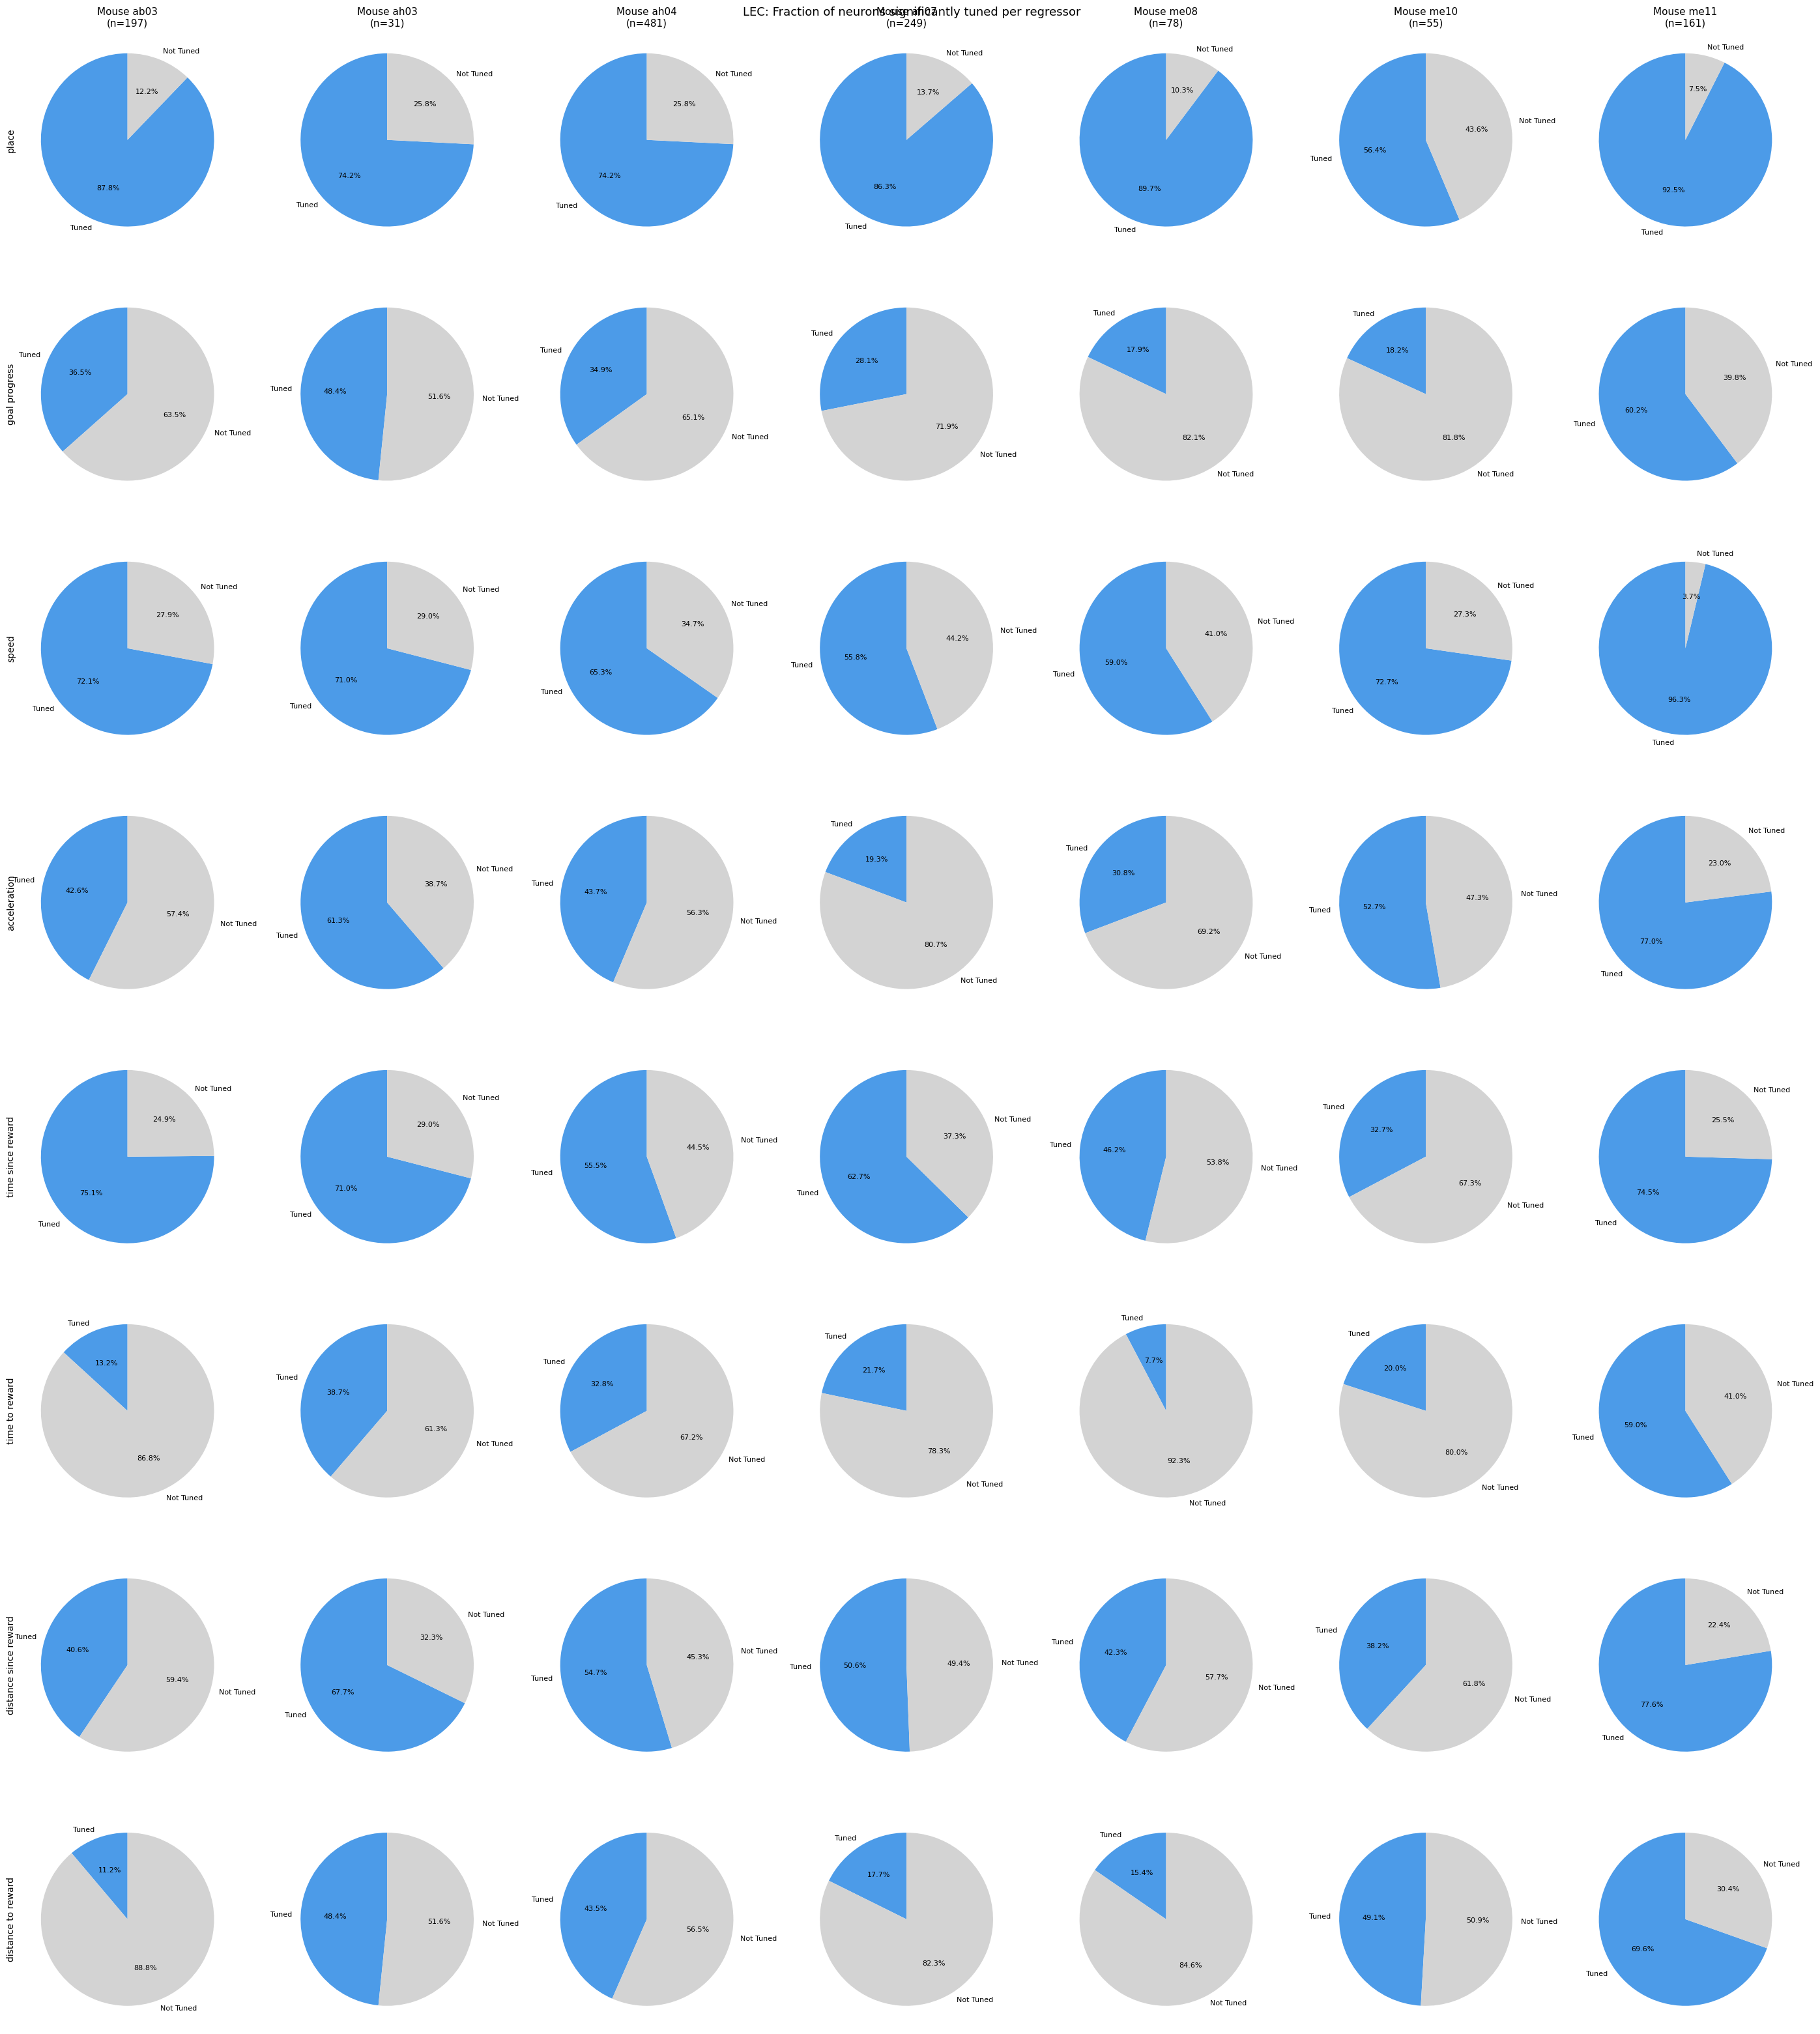

save_section('baseline'): wrote 2 file(s) to ../glm_outputs/PFC


['../glm_outputs/PFC/baseline__tuned_dict.pkl',
 '../glm_outputs/PFC/baseline__mouse_tuning_concat.pkl']

In [36]:
tuned_dict = compute_tuning_arrays(
    GLM_results, Permutation_results,
    regressors_to_include=PFC_REGRESSORS,
)
mouse_tuning_concat = group_tuning_by_mouse(tuned_dict)
plot_tuning_piecharts_binary(mouse_tuning_concat,
                             regressors_to_include=PFC_REGRESSORS)

save_section('baseline', SAVE_DIR,
             results={'tuned_dict': tuned_dict,
                      'mouse_tuning_concat': mouse_tuning_concat},
             fig_names=['pies'])


## Sanity check: decile distributions

Pools the same values that `run_glm_analysis` feeds to `compute_decile_edges`
(after the `Locs <= 21` filter, after downsampling), and overlays the chosen
decile boundaries plus the 1st/99th-percentile clip lines. Quick visual
confirmation that each variable's bins land where you'd expect — e.g. that
`time_from_reward` isn't so spiky at 0 that several deciles collapse.

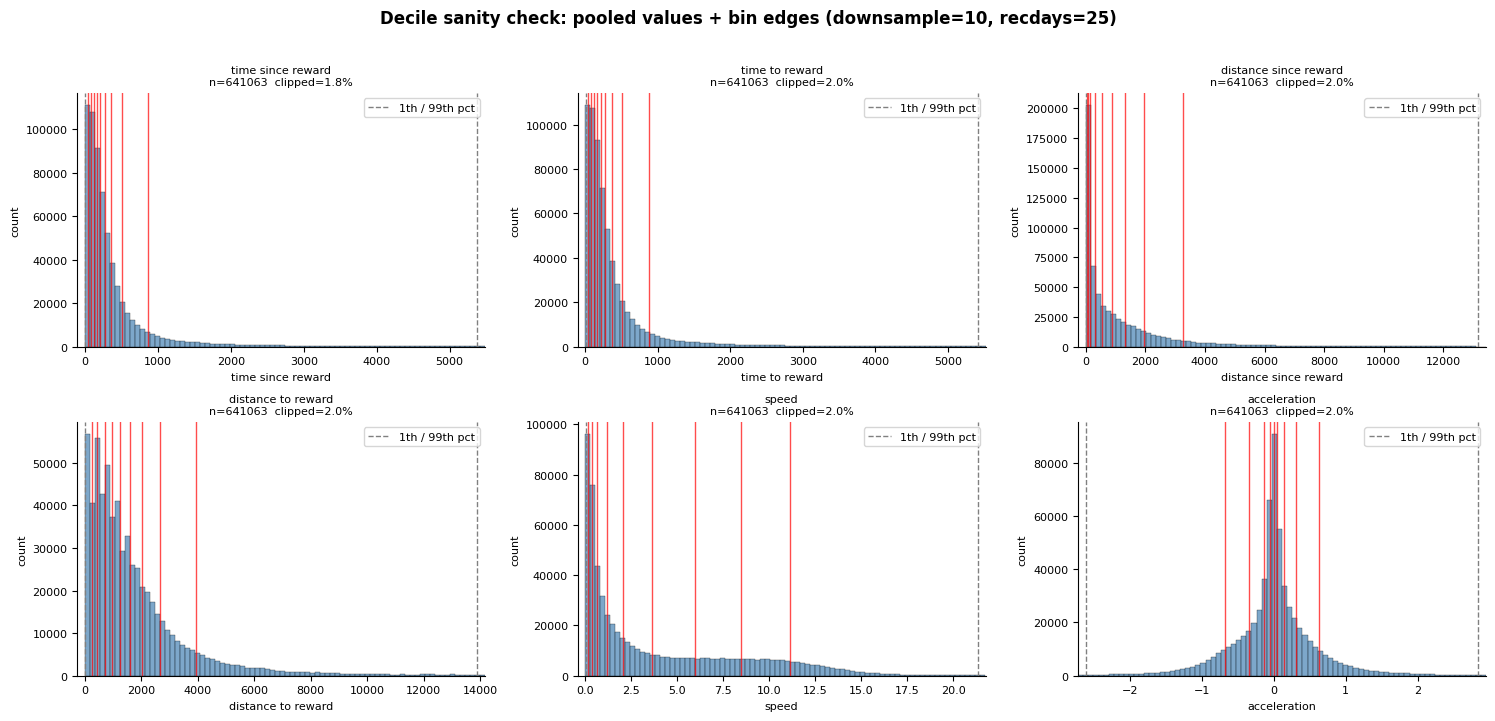

save_section('decile_check'): wrote 1 file(s) to ../glm_outputs/PFC


['../glm_outputs/PFC/decile_check__pooled.pkl']

In [37]:
from glm_analysis_v2 import plot_decile_distributions
pooled = plot_decile_distributions(mouse_recdays, data_dic)

save_section('decile_check', SAVE_DIR,
             results={'pooled': pooled},
             fig_names=['decile_dists'])


## No-lookahead variant

Drops `time_to_reward` and `distance_to_reward`. Tests whether the
goal-progress signal survives without forward-looking variables (whose
information about the upcoming reward is partly tautological with goal
progress).

run_or_load_glm('no_lookahead'): no cache (or force_refit) — fitting


Processing recording days:   0%|          | 0/25 [00:00<?, ?it/s]


ab03_01092023_02092023


/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/code/glm_analysis_v2.py:881: RuntimeWarning: invalid value encountered in cast
  'speed':                Sp_enc,


  Design matrix: 26462 rows × 71 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'distance_from_reward'], parameterization=all_bins)


...


me11_09122021_10122021
  Design matrix: 27028 rows × 71 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'distance_from_reward'], parameterization=all_bins)


Processing recording days:  96%|█████████▌| 24/25 [13:40<00:21, 21.54s/it]


me11_12122021_13122021
  Design matrix: 24771 rows × 71 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'distance_from_reward'], parameterization=all_bins)


Processing recording days: 100%|██████████| 25/25 [13:48<00:00, 33.15s/it]


run_or_load_glm('no_lookahead'): saved 2 pickle(s) to ../glm_outputs/PFC
ab03_01092023_02092023: tuning array shape = (63, 6)
ab03_05092023_06092023: tuning array shape = (64, 6)
ab03_29082023_30082023: tuning array shape = (70, 6)
ah03_12082021_13082021: tuning array shape = (16, 6)
ah03_18082021_19082021: tuning array shape = (15, 6)
ah04_01122021_02122021: tuning array shape = (117, 6)
ah04_05122021_06122021: tuning array shape = (114, 6)
ah04_07122021_08122021: tuning array shape = (81, 6)
ah04_09122021_10122021: tuning array shape = (99, 6)
ah04_14122021_16122021: tuning array shape = (70, 6)
ah07_01092023_02092023: tuning array shape = (97, 6)
ah07_27082023_28082023: tuning array shape = (80, 6)
ah07_29082023_30082023: tuning array shape = (72, 6)
me08_06092021_09092021: tuning array shape = (23, 6)
me08_10092021_11092021: tuning array shape = (32, 6)
me08_12092021_13092021: tuning array shape = (23, 6)
me10_09122021_10122021: tuning array shape = (28, 6)
me10_14122021_15122021: 

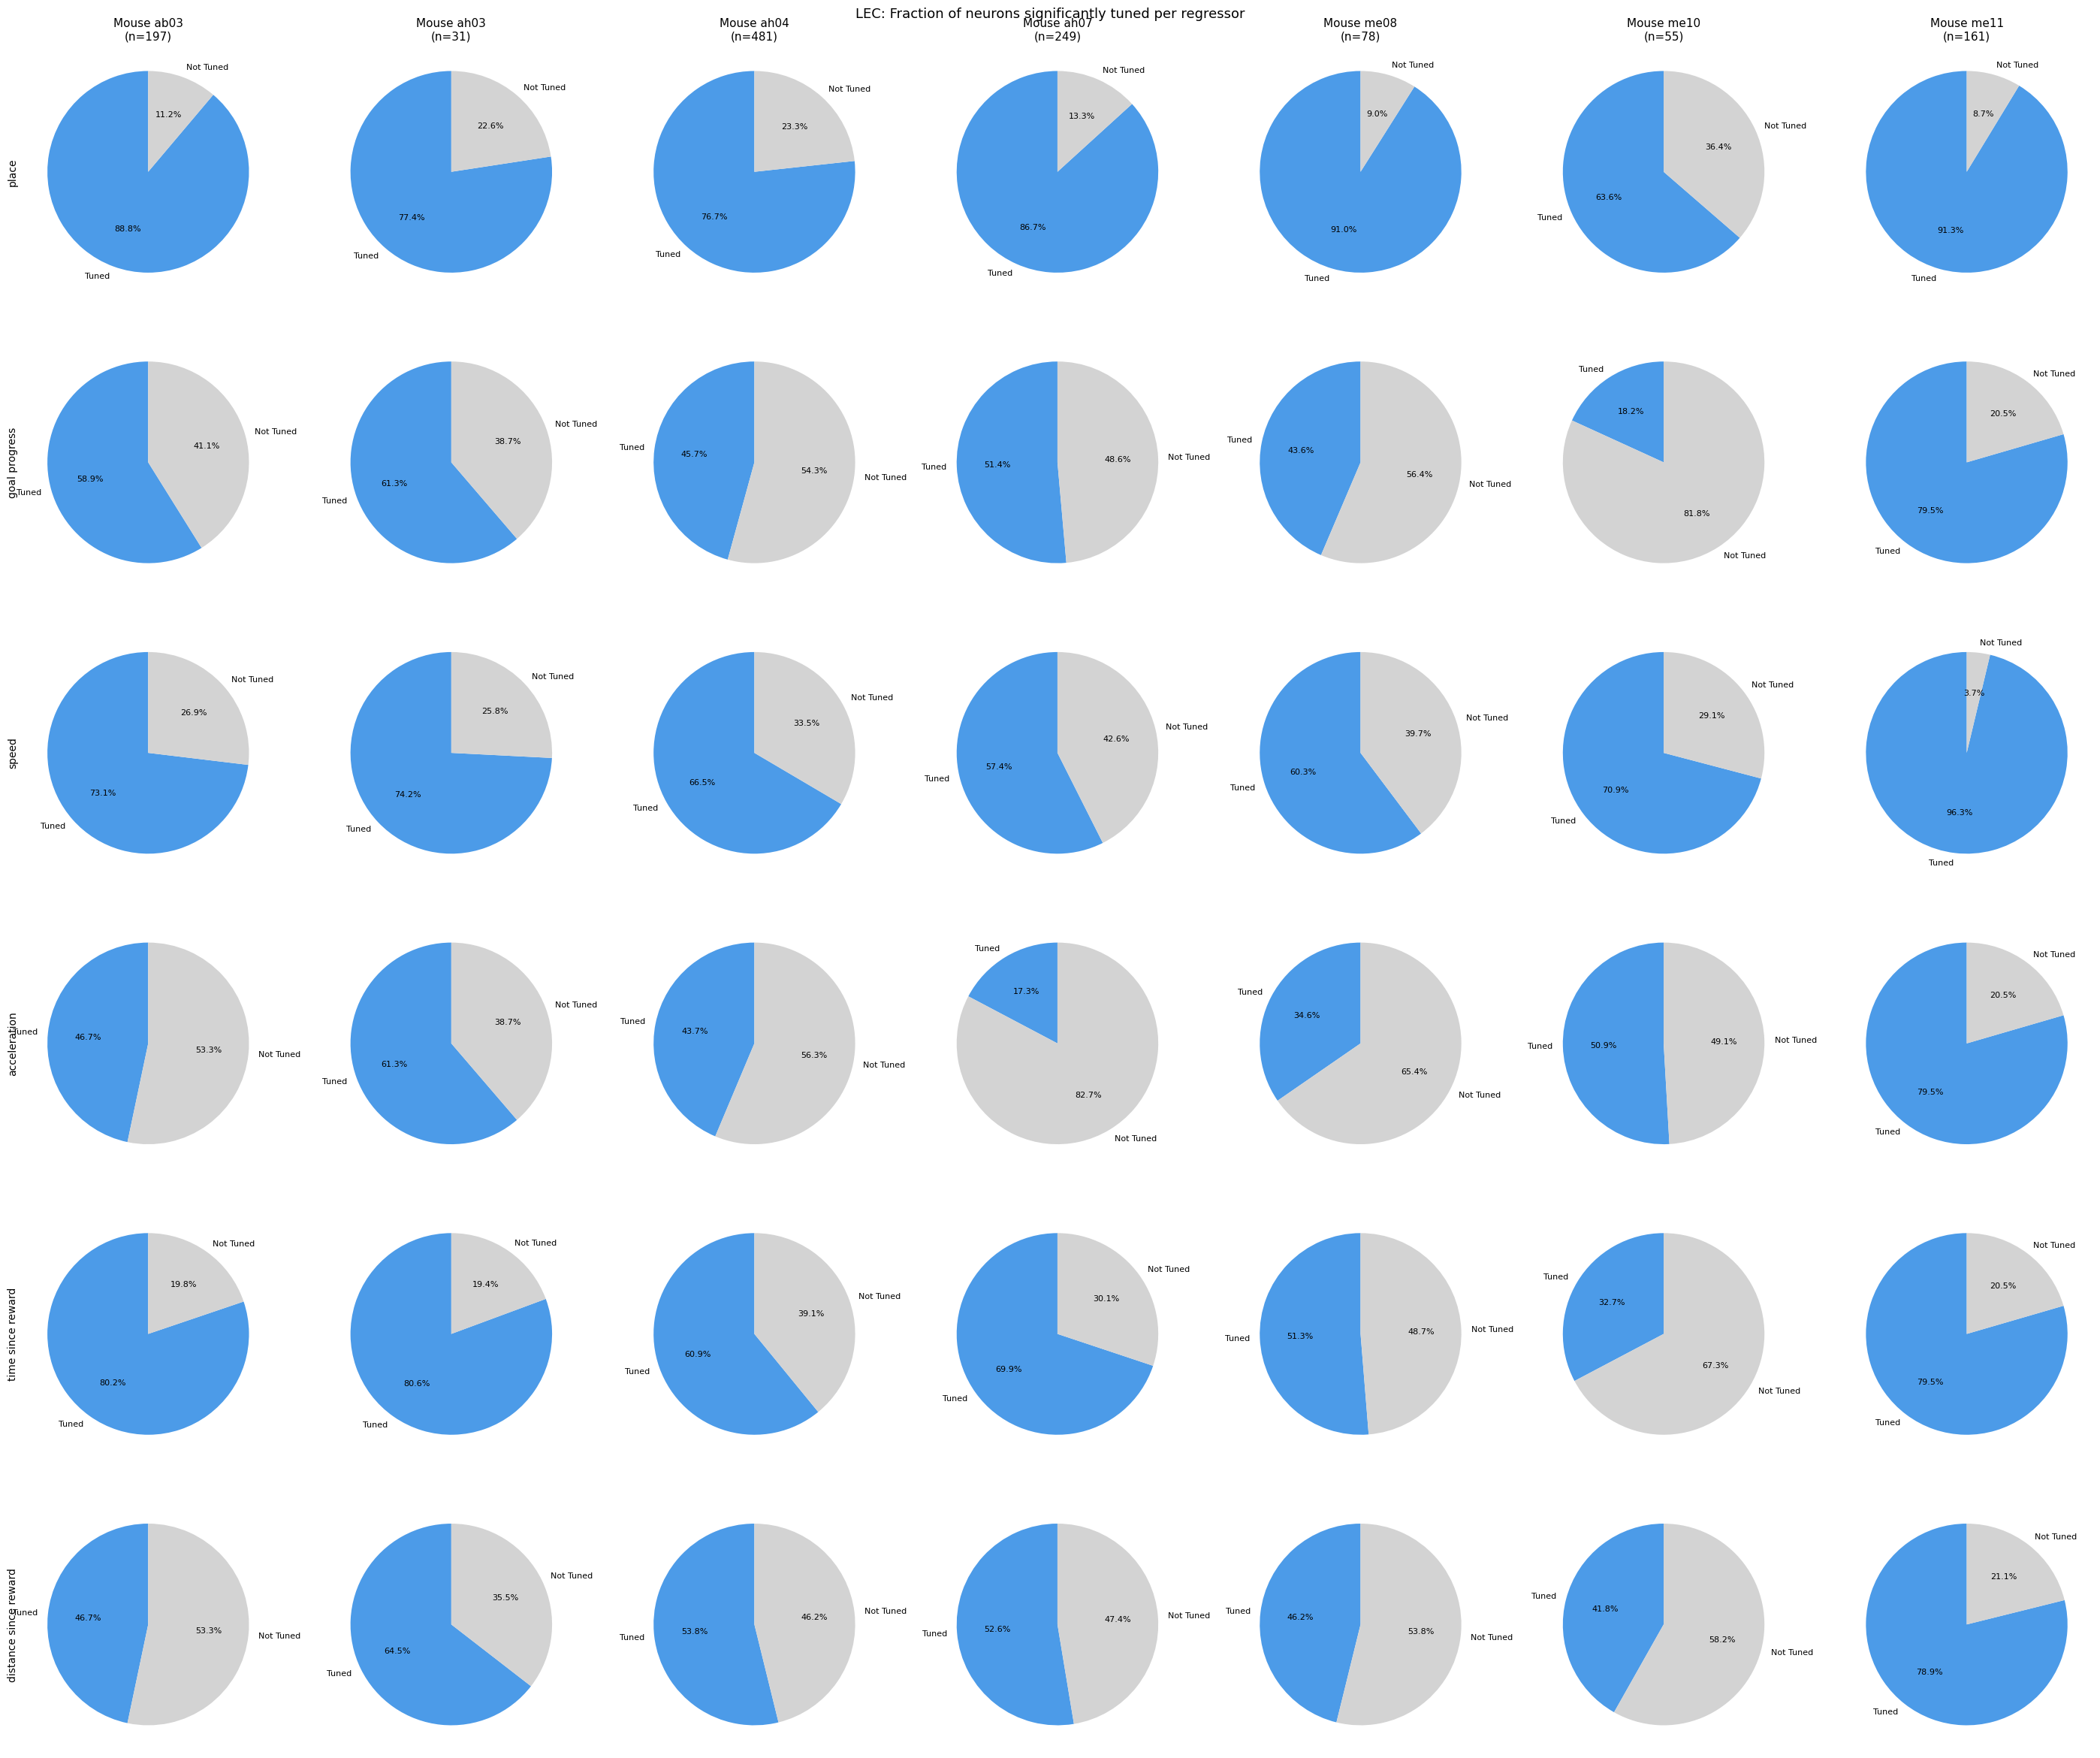

save_section('no_lookahead'): wrote 2 file(s) to ../glm_outputs/PFC


['../glm_outputs/PFC/no_lookahead__tuned_dict.pkl',
 '../glm_outputs/PFC/no_lookahead__mouse_tuning_concat.pkl']

In [38]:
PFC_REGRESSORS_NL = ['place', 'goal_progress', 'speed', 'acceleration',
                     'time_since_reward', 'distance_since_reward']

GLM_results_nl, Permutation_results_nl = run_or_load_glm(
    mouse_recdays, data_dic, SAVE_DIR, 'no_lookahead',
    regressors_to_include=PFC_REGRESSORS_NL,
)
tuned_dict_nl = compute_tuning_arrays(
    GLM_results_nl, Permutation_results_nl,
    regressors_to_include=PFC_REGRESSORS_NL,
)
mouse_tuning_concat_nl = group_tuning_by_mouse(tuned_dict_nl)
plot_tuning_piecharts_binary(mouse_tuning_concat_nl,
                             regressors_to_include=PFC_REGRESSORS_NL)

save_section('no_lookahead', SAVE_DIR,
             results={'tuned_dict': tuned_dict_nl,
                      'mouse_tuning_concat': mouse_tuning_concat_nl},
             fig_names=['pies'])


## Extended analysis: CPD + joint `time_any` group

Re-fits with `compute_cpd=True` and a joint test of "any time information"
(`time_since` + `time_to` dropped together). Produces the headline GP-vs-time
comparison: simplified pies, time-vs-progress overlap stacked bars, per-neuron
CPD scatter.

In [39]:
reload(glm_analysis_v2)
from glm_analysis_v2 import (
    run_glm_analysis, plot_time_vs_progress_overlap, plot_cpd_time_vs_progress,
)

GLM_results_ext, Permutation_results_ext, CPD_results_ext = run_or_load_glm(
    mouse_recdays, data_dic, SAVE_DIR, 'extended_cpd',
    regressors_to_include=PFC_REGRESSORS,
    compute_cpd=True,
    joint_drop_groups=[('time_any', ['time_since_reward', 'time_to_reward'])],
)
print('Done. CPD and joint time_any stored.')

run_or_load_glm('extended_cpd'): no cache (or force_refit) — fitting


Processing recording days:   0%|          | 0/25 [00:00<?, ?it/s]


ab03_01092023_02092023


/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/code/glm_analysis_v2.py:881: RuntimeWarning: invalid value encountered in cast
  'speed':                Sp_enc,


  Design matrix: 26462 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


...


me11_09122021_10122021
  Design matrix: 27028 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  96%|█████████▌| 24/25 [24:10<00:37, 37.84s/it]


me11_12122021_13122021
  Design matrix: 24771 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days: 100%|██████████| 25/25 [24:24<00:00, 58.58s/it]

run_or_load_glm('extended_cpd'): saved 3 pickle(s) to ../glm_outputs/PFC
Done. CPD and joint time_any stored.


ab03_01092023_02092023: tuning array shape = (63, 8)
ab03_05092023_06092023: tuning array shape = (64, 8)
ab03_29082023_30082023: tuning array shape = (70, 8)
ah03_12082021_13082021: tuning array shape = (16, 8)
ah03_18082021_19082021: tuning array shape = (15, 8)
ah04_01122021_02122021: tuning array shape = (117, 8)
ah04_05122021_06122021: tuning array shape = (114, 8)
ah04_07122021_08122021: tuning array shape = (81, 8)
ah04_09122021_10122021: tuning array shape = (99, 8)
ah04_14122021_16122021: tuning array shape = (70, 8)
ah07_01092023_02092023: tuning array shape = (97, 8)
ah07_27082023_28082023: tuning array shape = (80, 8)
ah07_29082023_30082023: tuning array shape = (72, 8)
me08_06092021_09092021: tuning array shape = (23, 8)
me08_10092021_11092021: tuning array shape = (32, 8)
me08_12092021_13092021: tuning array shape = (23, 8)
me10_09122021_10122021: tuning array shape = (28, 8)
me10_14122021_15122021: tuning array shape = (20, 8)
me10_17122021_19122021: tuning array shape =

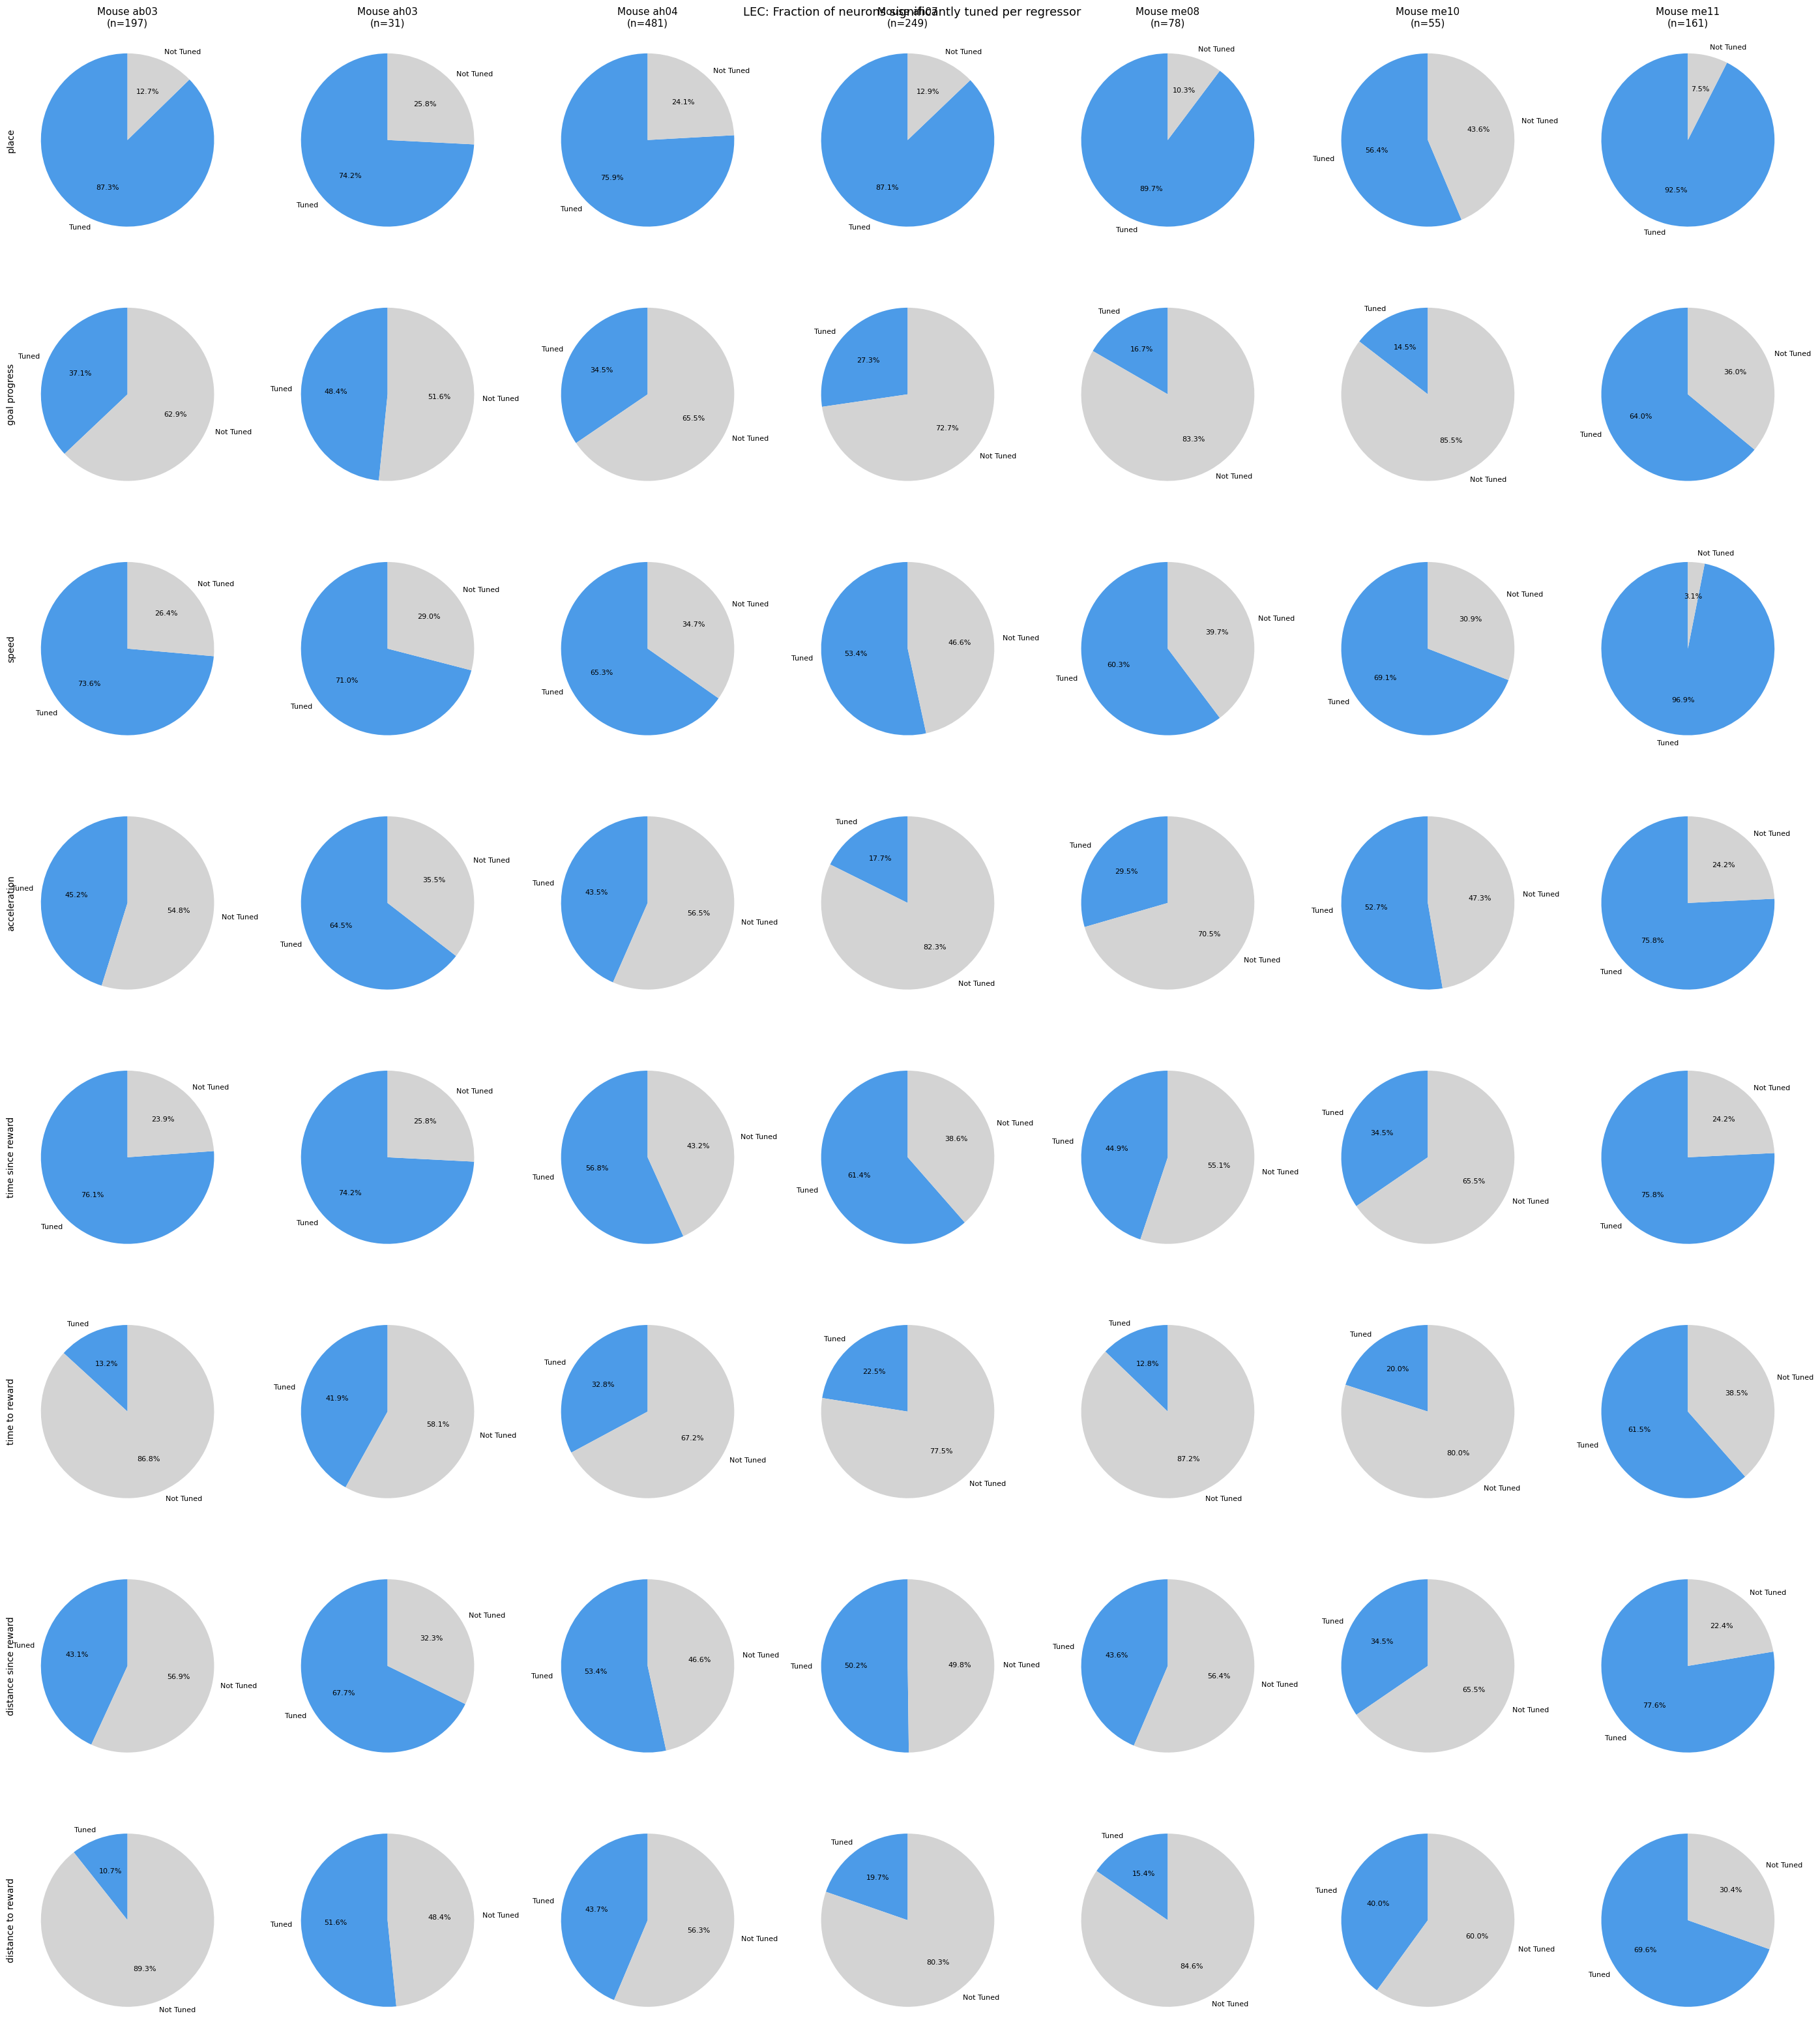

In [40]:
tuned_dict_ext = compute_tuning_arrays(
    GLM_results_ext, Permutation_results_ext,
    regressors_to_include=PFC_REGRESSORS,
)
mouse_tuning_concat_ext = group_tuning_by_mouse(tuned_dict_ext)
plot_tuning_piecharts_binary(mouse_tuning_concat_ext,
                             regressors_to_include=PFC_REGRESSORS)

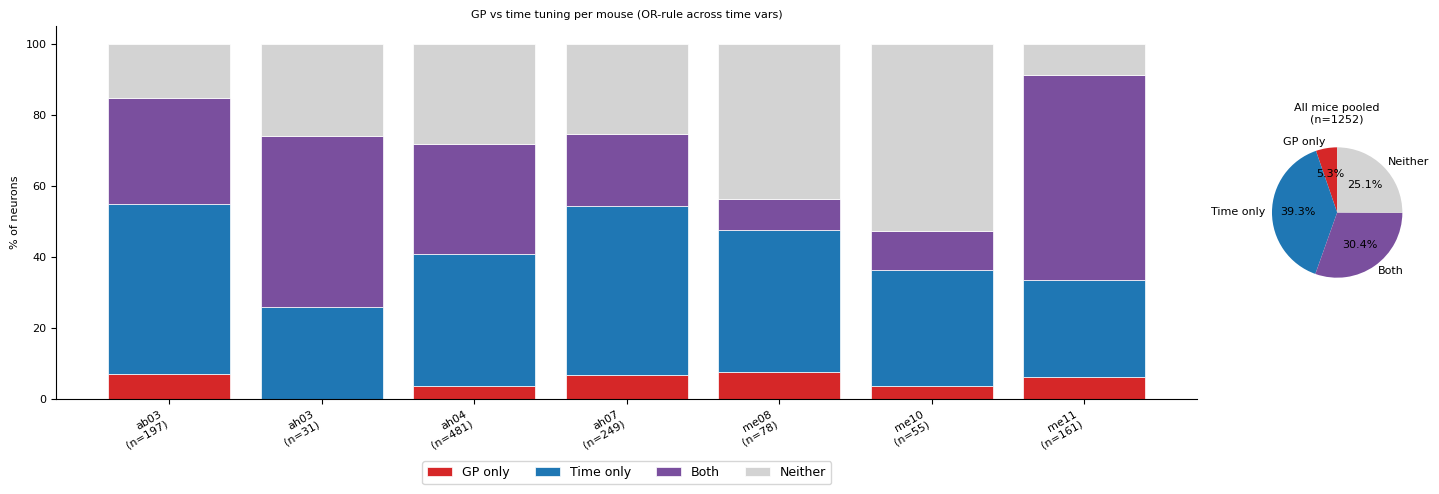

In [41]:
plot_time_vs_progress_overlap(mouse_tuning_concat_ext,
                              regressors_to_include=PFC_REGRESSORS,
                              use_joint_time=False)

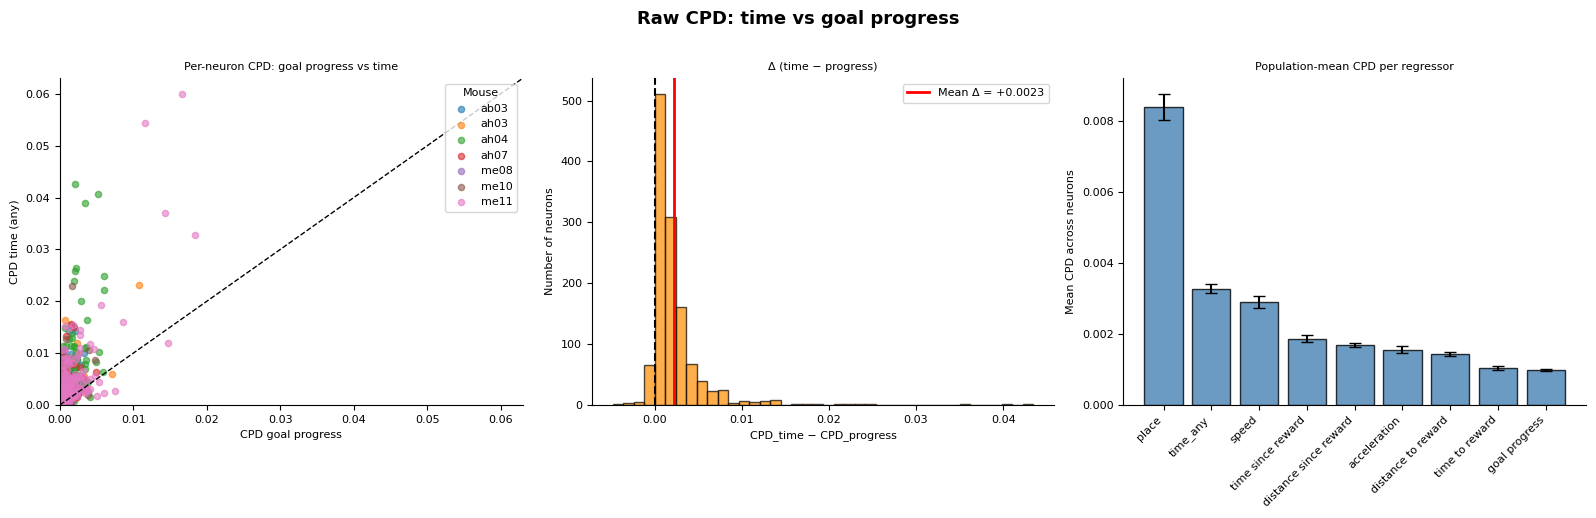

Per-mouse mean Δ (CPD_time_any − CPD_progress):
  ab03: μ=+0.00224  n=197
  ah03: μ=+0.00358  n=31
  ah04: μ=+0.00219  n=481
  ah07: μ=+0.00185  n=249
  me08: μ=+0.00145  n=78
  me10: μ=+0.00255  n=55
  me11: μ=+0.00335  n=161
save_section('extended_cpd'): wrote 3 file(s) to ../glm_outputs/PFC


['../glm_outputs/PFC/extended_cpd__tuned_dict.pkl',
 '../glm_outputs/PFC/extended_cpd__mouse_tuning_concat.pkl',
 '../glm_outputs/PFC/extended_cpd__by_mouse_diff.pkl']

In [42]:
cpd_gp, cpd_time = plot_cpd_time_vs_progress(CPD_results_ext, group_by_mouse=True)

by_mouse_diff = defaultdict(list)
for mr, neuron_dict in CPD_results_ext.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        g = cpd.get('goal_progress', np.nan)
        t = cpd.get('time_any', np.nan)
        if not (np.isnan(g) or np.isnan(t)):
            by_mouse_diff[mouse].append(t - g)

print('Per-mouse mean Δ (CPD_time_any − CPD_progress):')
for mouse in sorted(by_mouse_diff.keys()):
    diffs = np.array(by_mouse_diff[mouse])
    print(f'  {mouse}: μ={diffs.mean():+.5f}  n={len(diffs)}')

save_section('extended_cpd', SAVE_DIR,
             results={'tuned_dict': tuned_dict_ext,
                      'mouse_tuning_concat': mouse_tuning_concat_ext,
                      'by_mouse_diff': dict(by_mouse_diff)},
             fig_names=['pies', 'overlap', 'cpd_scatter'])


## Firming up: full-model R², normalized CPD, column-matched

Anchors CPD magnitudes with model-fit quality and runs a column-matched
single-regressor comparison (GP 10 cols vs `time_since_reward` 10 cols).

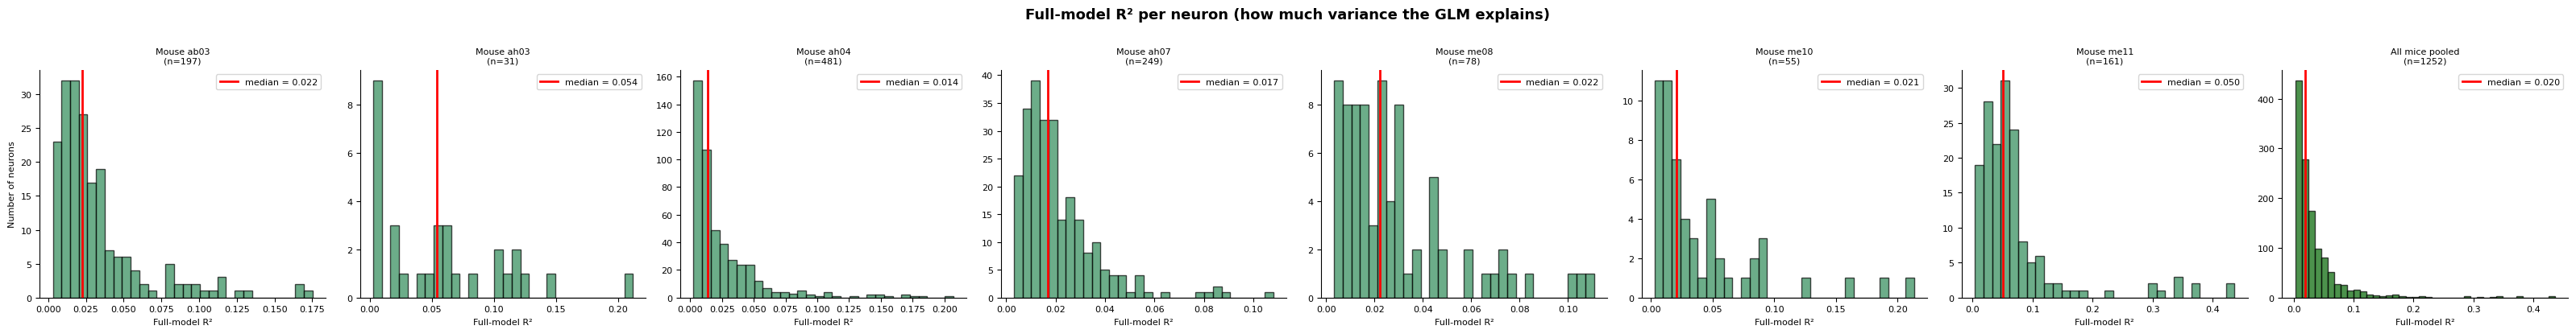

{'ab03': array([0.0155833 , 0.00728194, 0.00478292, 0.02465194, 0.02033797,
        0.00526981, 0.00918906, 0.04280396, 0.04098885, 0.03536839,
        0.01724177, 0.01461308, 0.01699959, 0.11762688, 0.01730089,
        0.04318316, 0.01990723, 0.04311057, 0.01885739, 0.0957751 ,
        0.03895114, 0.17521583, 0.02581052, 0.08155223, 0.0454704 ,
        0.04835643, 0.01251656, 0.09485768, 0.12433311, 0.16656097,
        0.03708478, 0.10222331, 0.035784  , 0.01207119, 0.03048967,
        0.07829622, 0.02338705, 0.02599042, 0.03242666, 0.00873816,
        0.01232944, 0.00911763, 0.0090127 , 0.00636557, 0.00402825,
        0.00786255, 0.01349714, 0.02021159, 0.01837558, 0.02192798,
        0.02775374, 0.03146004, 0.02368507, 0.02446592, 0.01311975,
        0.05947503, 0.00396971, 0.0634529 , 0.01628549, 0.018958  ,
        0.02170923, 0.00332086, 0.04752517, 0.02345802, 0.0290089 ,
        0.02175274, 0.00961541, 0.00922923, 0.00583195, 0.00729053,
        0.02180978, 0.02499337, 0.014740

In [43]:
from glm_analysis_v2 import plot_full_model_r2
plot_full_model_r2(CPD_results_ext)

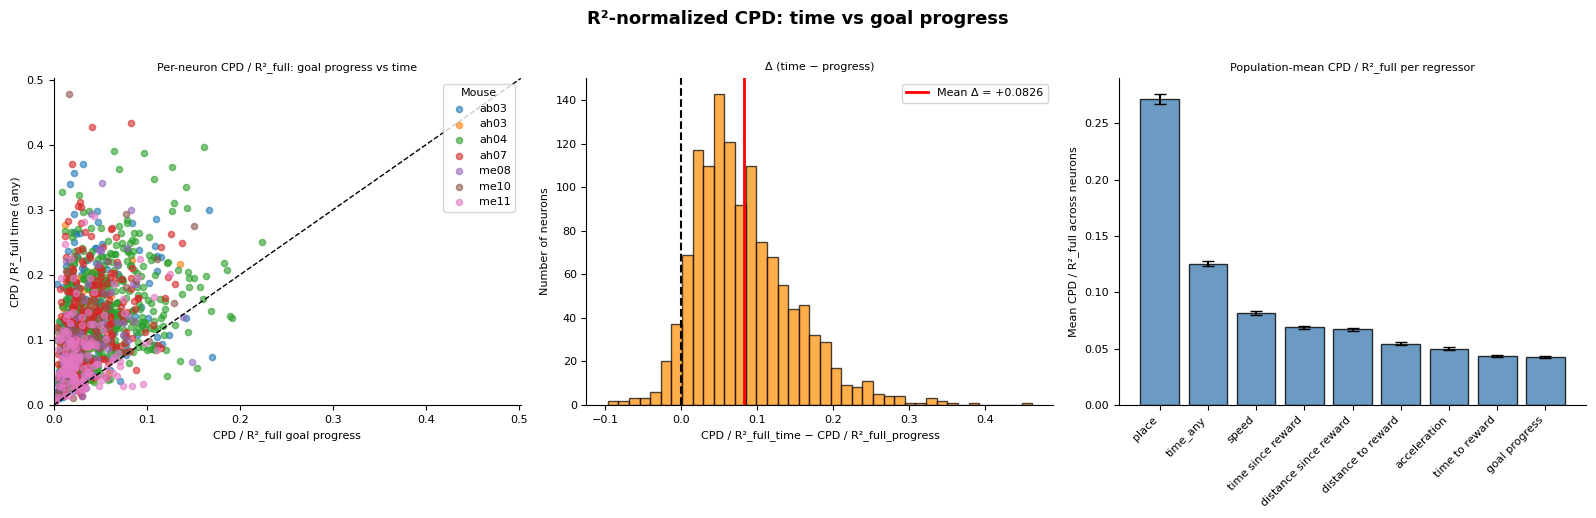

(array([0.02378667, 0.04369503, 0.14204939, ..., 0.09244871, 0.03935176,
        0.07071591]),
 array([0.08897575, 0.24158364, 0.13376112, ..., 0.22404321, 0.09869131,
        0.06820784]))

In [44]:
plot_cpd_time_vs_progress(CPD_results_ext, normalize='r2_full')

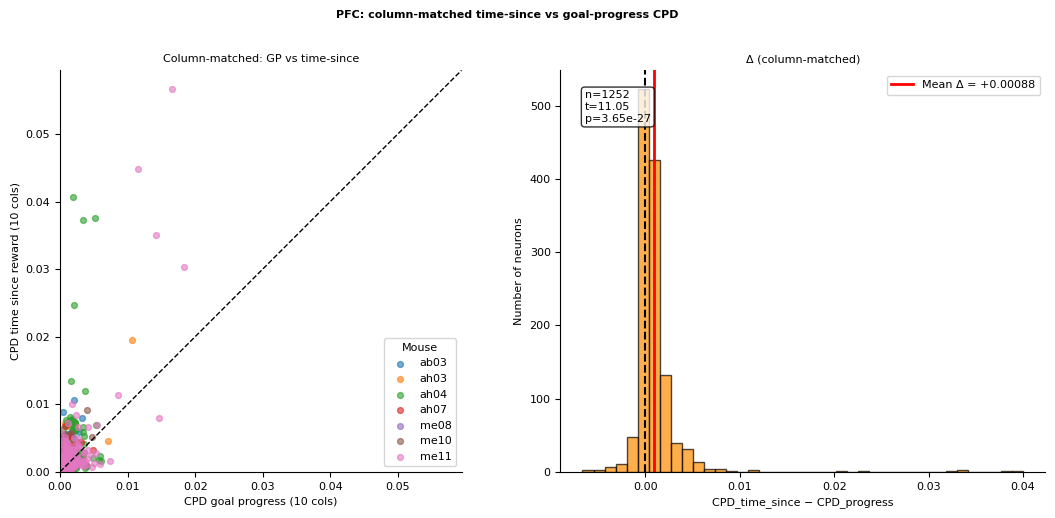

save_section('firming_up'): wrote 0 file(s) to ../glm_outputs/PFC


[]

In [45]:
# Column-matched: GP(10) vs time_since(10) — single-regressor, NOT joint.
gp_cpd, ts_cpd, mouse_tag = [], [], []
for mr, neuron_dict in CPD_results_ext.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        g = cpd.get('goal_progress', np.nan)
        t = cpd.get('time_from_reward', np.nan)  # canonical = time_since_reward
        if np.isfinite(g) and np.isfinite(t):
            gp_cpd.append(g); ts_cpd.append(t); mouse_tag.append(mouse)
gp_cpd = np.array(gp_cpd); ts_cpd = np.array(ts_cpd); mouse_tag = np.array(mouse_tag)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
for i, mouse in enumerate(sorted(np.unique(mouse_tag))):
    msk = mouse_tag == mouse
    ax.scatter(gp_cpd[msk], ts_cpd[msk], alpha=0.6, s=18,
               color=plt.get_cmap('tab10')(i % 10), label=mouse)
lim = max(0.001, max(gp_cpd.max(), ts_cpd.max()) * 1.05)
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
ax.set_xlabel('CPD goal progress (10 cols)')
ax.set_ylabel('CPD time since reward (10 cols)')
ax.set_title('Column-matched: GP vs time-since')
ax.legend(fontsize=8, title='Mouse')

ax = axes[1]
d = ts_cpd - gp_cpd
ax.hist(d, bins=40, color='darkorange', alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(d.mean(), color='red', lw=2, label=f'Mean Δ = {d.mean():+.5f}')
tval, pval = st.ttest_1samp(d, 0)
ax.text(0.05, 0.95, f'n={len(d)}\nt={tval:.2f}\np={pval:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('CPD_time_since − CPD_progress')
ax.set_ylabel('Number of neurons')
ax.set_title('Δ (column-matched)')
ax.legend()
plt.suptitle('PFC: column-matched time-since vs goal-progress CPD', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

save_section('firming_up', SAVE_DIR,
             fig_names=['r2_full', 'normalized_cpd', 'column_matched'])


## Raised-cosine basis variant (robustness check)

Refits with smooth raised-cosine bumps in place of hard decile binning for the
continuous regressors. If the time-vs-progress conclusion survives, it isn't
an artefact of the hard-binning choice.

run_or_load_glm('raised_cosine'): no cache (or force_refit) — fitting


Processing recording days:   0%|          | 0/25 [00:00<?, ?it/s]


ab03_01092023_02092023


/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/code/glm_analysis_v2.py:881: RuntimeWarning: invalid value encountered in cast
  'speed':                Sp_enc,


  Design matrix: 26462 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


...


me11_09122021_10122021
  Design matrix: 27028 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  96%|█████████▌| 24/25 [25:06<00:38, 38.87s/it]


me11_12122021_13122021
  Design matrix: 24771 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days: 100%|██████████| 25/25 [25:20<00:00, 60.83s/it]


run_or_load_glm('raised_cosine'): saved 3 pickle(s) to ../glm_outputs/PFC
ab03_01092023_02092023: tuning array shape = (63, 8)
ab03_05092023_06092023: tuning array shape = (64, 8)
ab03_29082023_30082023: tuning array shape = (70, 8)
ah03_12082021_13082021: tuning array shape = (16, 8)
ah03_18082021_19082021: tuning array shape = (15, 8)
ah04_01122021_02122021: tuning array shape = (117, 8)
ah04_05122021_06122021: tuning array shape = (114, 8)
ah04_07122021_08122021: tuning array shape = (81, 8)
ah04_09122021_10122021: tuning array shape = (99, 8)
ah04_14122021_16122021: tuning array shape = (70, 8)
ah07_01092023_02092023: tuning array shape = (97, 8)
ah07_27082023_28082023: tuning array shape = (80, 8)
ah07_29082023_30082023: tuning array shape = (72, 8)
me08_06092021_09092021: tuning array shape = (23, 8)
me08_10092021_11092021: tuning array shape = (32, 8)
me08_12092021_13092021: tuning array shape = (23, 8)
me10_09122021_10122021: tuning array shape = (28, 8)
me10_14122021_15122021:

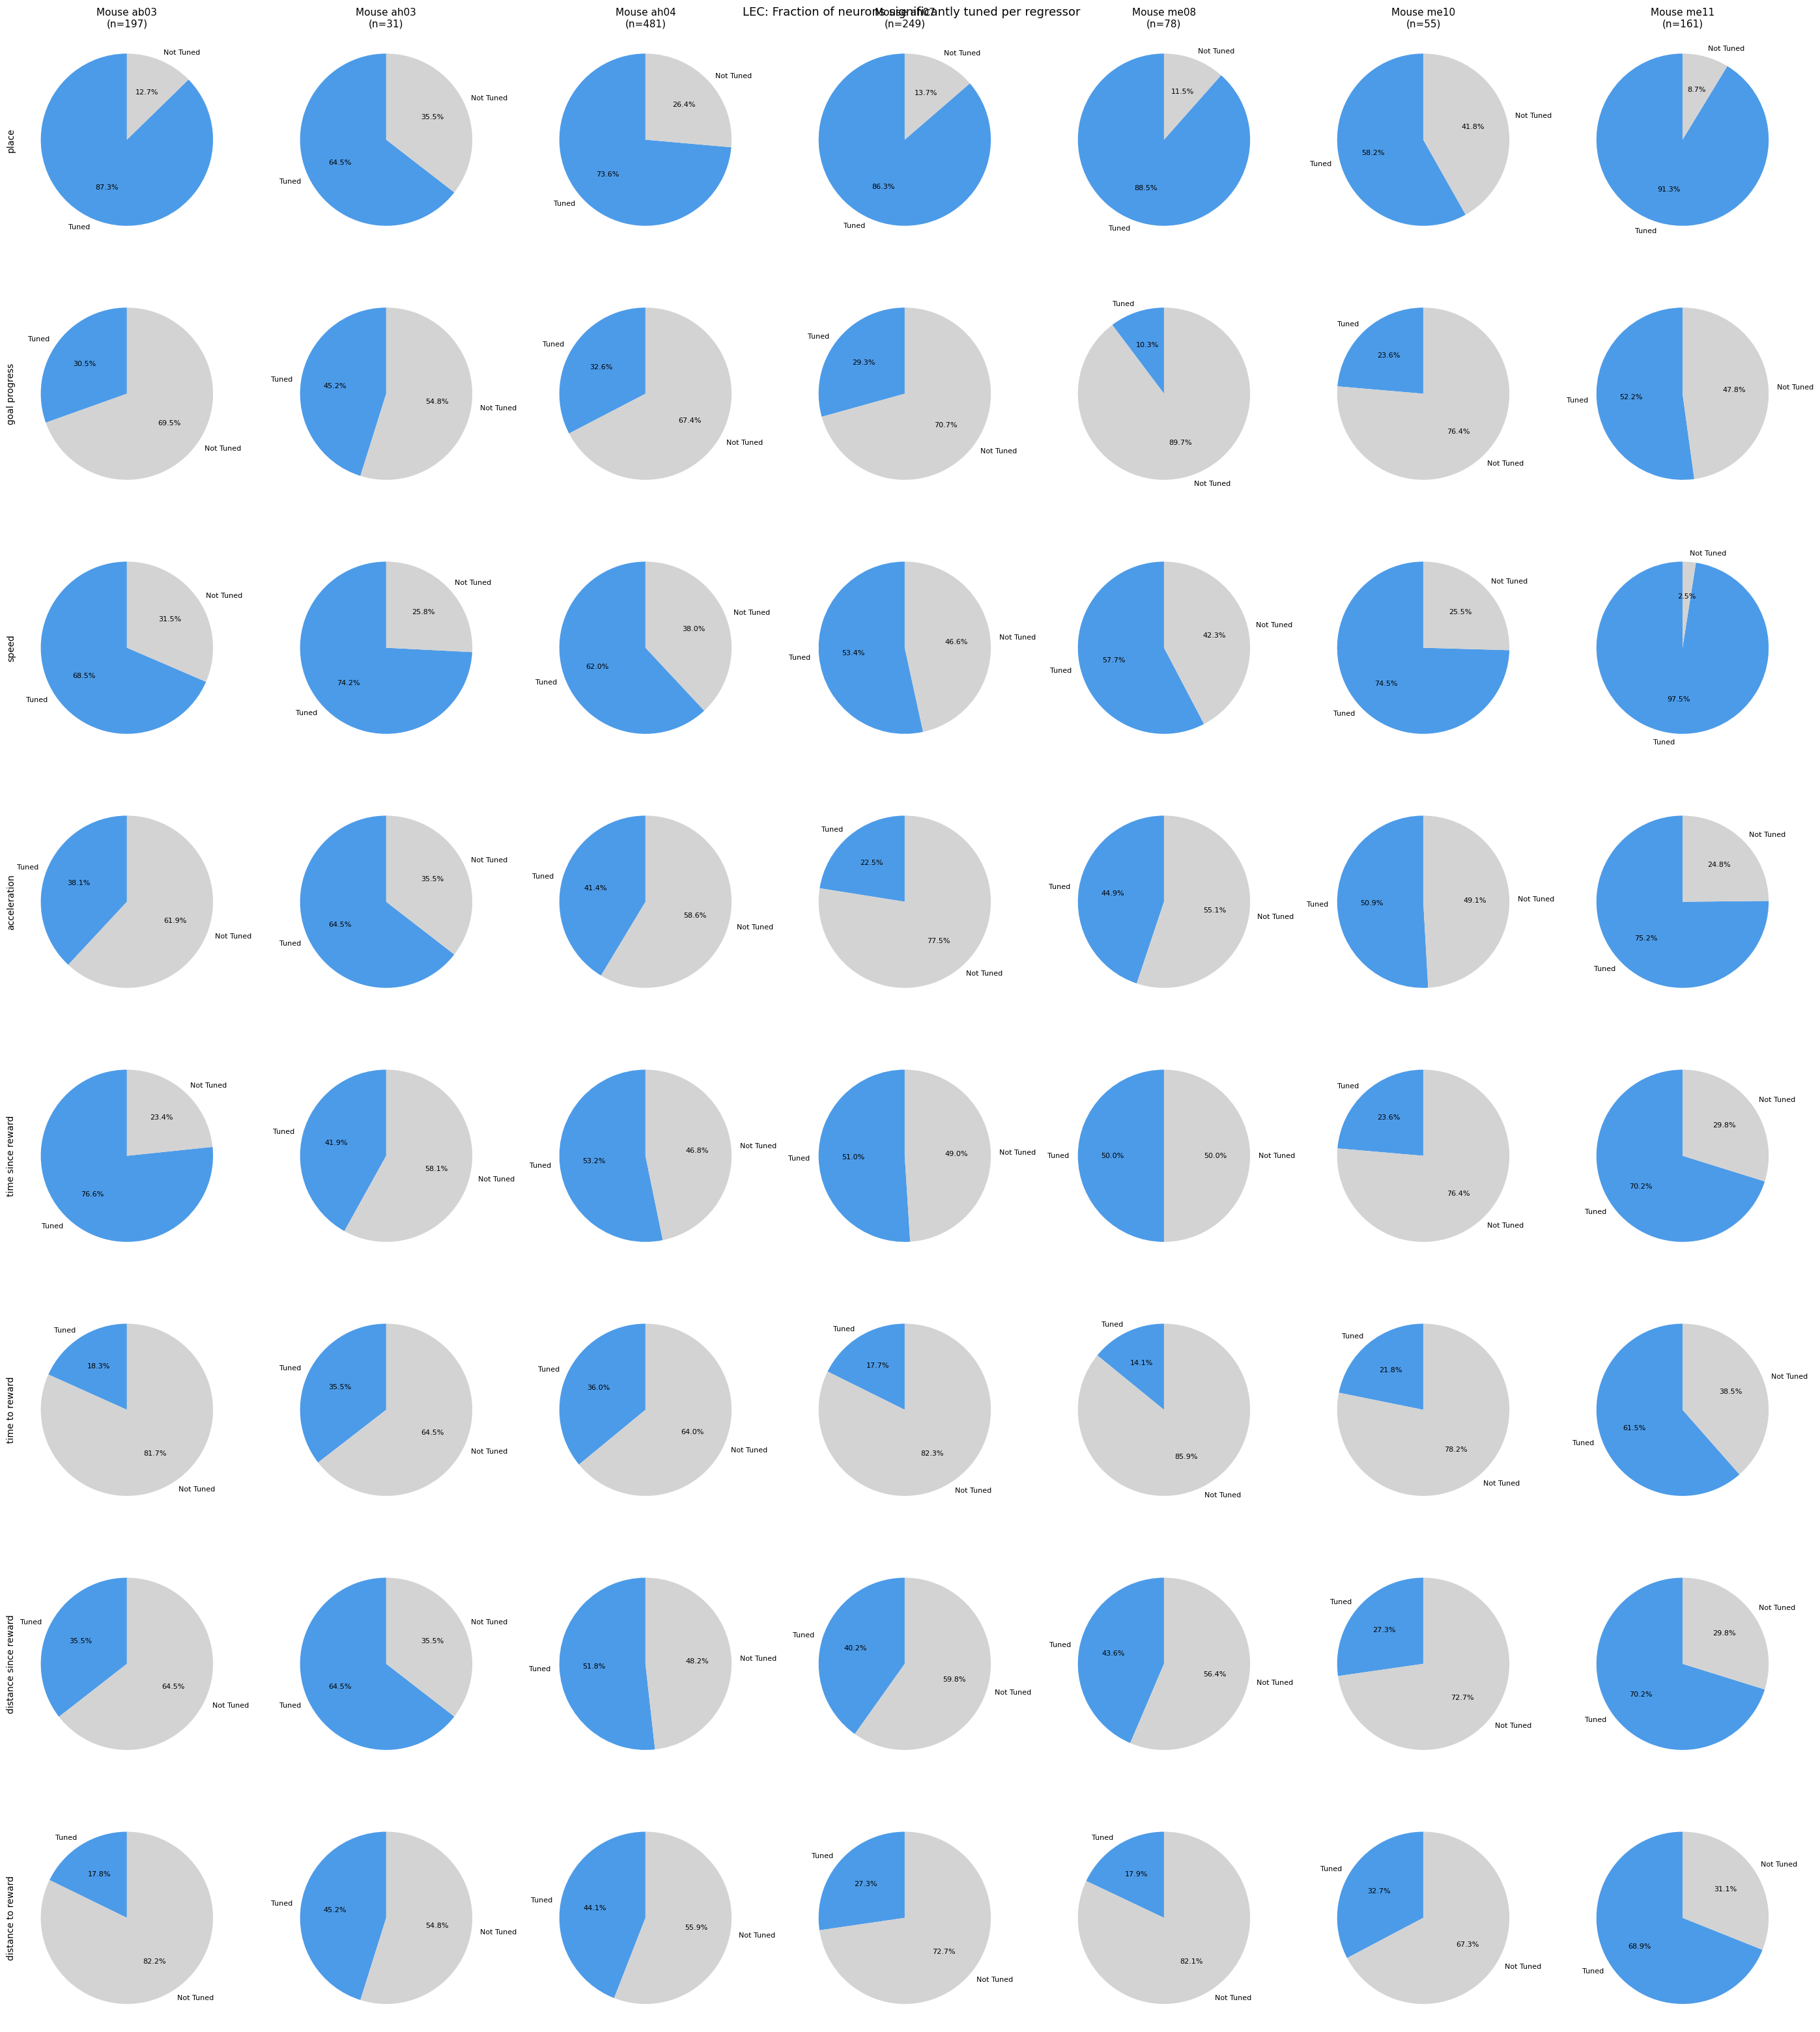

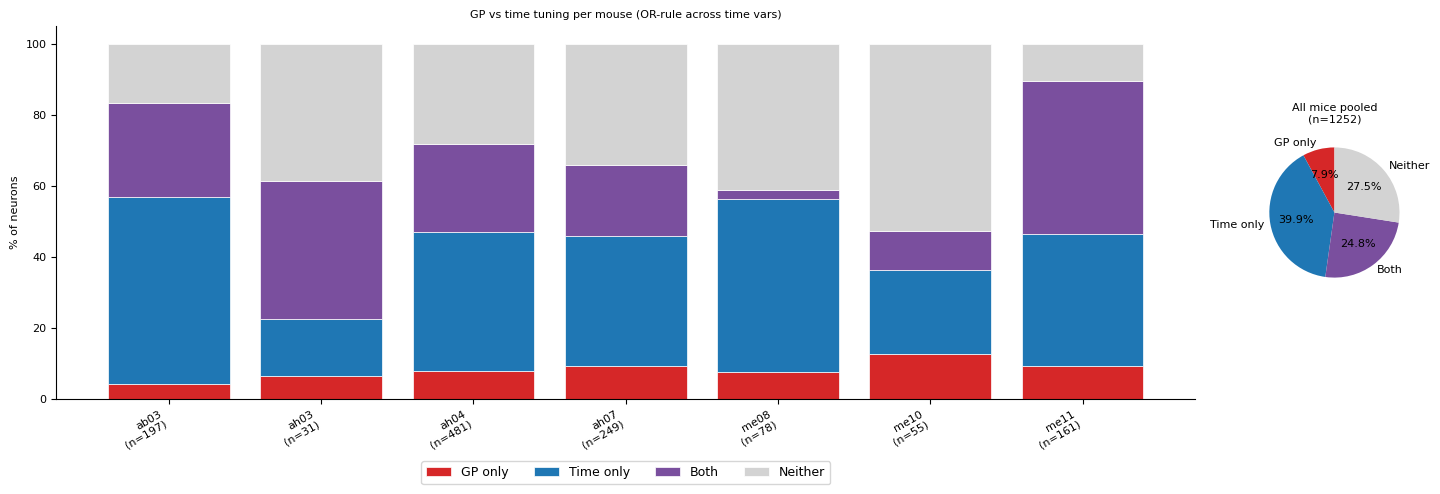

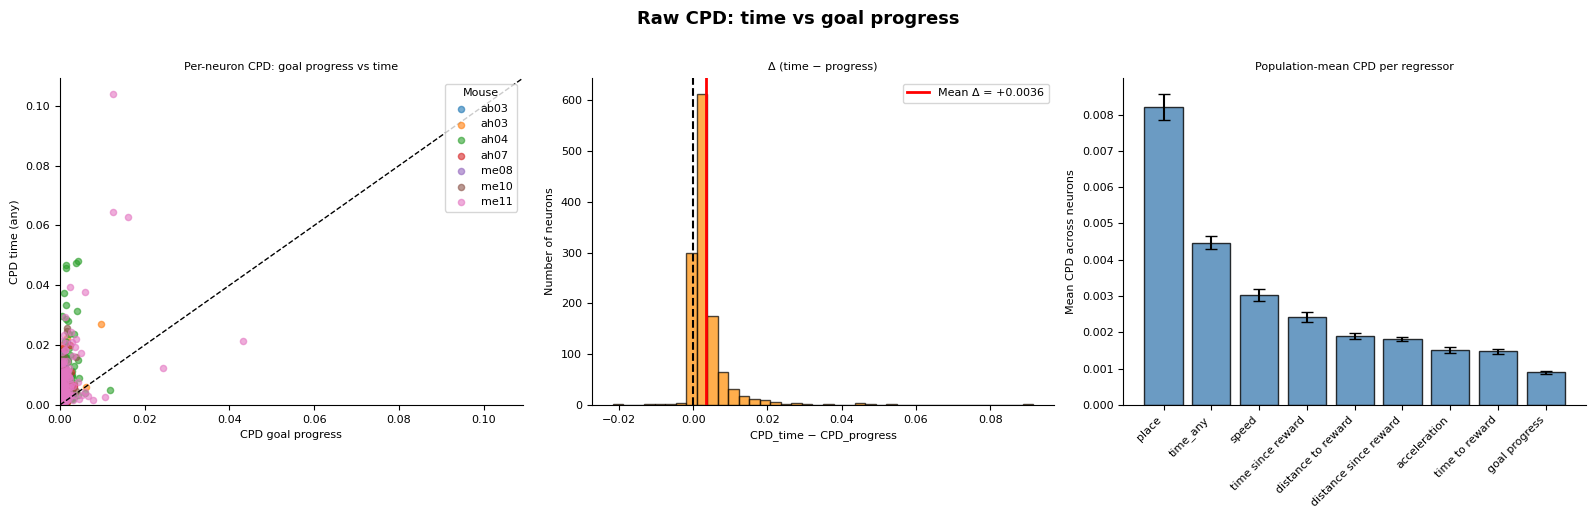

save_section('raised_cosine'): wrote 2 file(s) to ../glm_outputs/PFC


['../glm_outputs/PFC/raised_cosine__tuned_dict.pkl',
 '../glm_outputs/PFC/raised_cosine__mouse_tuning_concat.pkl']

In [46]:
GLM_results_rc, Permutation_results_rc, CPD_results_rc = run_or_load_glm(
    mouse_recdays, data_dic, SAVE_DIR, 'raised_cosine',
    regressors_to_include=PFC_REGRESSORS,
    compute_cpd=True,
    joint_drop_groups=[('time_any', ['time_since_reward', 'time_to_reward'])],
    continuous_basis='raised_cosine',
)
tuned_dict_rc = compute_tuning_arrays(
    GLM_results_rc, Permutation_results_rc,
    regressors_to_include=PFC_REGRESSORS,
)
mouse_tuning_concat_rc = group_tuning_by_mouse(tuned_dict_rc)
plot_tuning_piecharts_binary(mouse_tuning_concat_rc,
                             regressors_to_include=PFC_REGRESSORS)
plot_time_vs_progress_overlap(mouse_tuning_concat_rc,
                              regressors_to_include=PFC_REGRESSORS)
plot_cpd_time_vs_progress(CPD_results_rc)

save_section('raised_cosine', SAVE_DIR,
             results={'tuned_dict': tuned_dict_rc,
                      'mouse_tuning_concat': mouse_tuning_concat_rc},
             fig_names=['pies', 'overlap', 'cpd_scatter'])


## 20-bin GP column-matched (GP=20 vs joint `time_any`=20, `distance_any`=20)

`goal_progress` re-binned to 20 cols so it matches both joint 20-col groups.
Removes the column-count advantage that `time_any` / `distance_any` had over
the 10-bin GP in the extended section above. Design matrix grows from 91 to
101 cols.

run_or_load_glm('gp20'): no cache (or force_refit) — fitting


Processing recording days:   0%|          | 0/25 [00:00<?, ?it/s]


ab03_01092023_02092023


/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/code/glm_analysis_v2.py:881: RuntimeWarning: invalid value encountered in cast
  'speed':                Sp_enc,


  Design matrix: 26462 rows × 101 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


...


me11_09122021_10122021
  Design matrix: 27028 rows × 101 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  96%|█████████▌| 24/25 [30:12<00:50, 50.47s/it]


me11_12122021_13122021
  Design matrix: 24771 rows × 101 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days: 100%|██████████| 25/25 [30:32<00:00, 73.30s/it]


run_or_load_glm('gp20'): saved 3 pickle(s) to ../glm_outputs/PFC
ab03_01092023_02092023: tuning array shape = (63, 8)
ab03_05092023_06092023: tuning array shape = (64, 8)
ab03_29082023_30082023: tuning array shape = (70, 8)
ah03_12082021_13082021: tuning array shape = (16, 8)
ah03_18082021_19082021: tuning array shape = (15, 8)
ah04_01122021_02122021: tuning array shape = (117, 8)
ah04_05122021_06122021: tuning array shape = (114, 8)
ah04_07122021_08122021: tuning array shape = (81, 8)
ah04_09122021_10122021: tuning array shape = (99, 8)
ah04_14122021_16122021: tuning array shape = (70, 8)
ah07_01092023_02092023: tuning array shape = (97, 8)
ah07_27082023_28082023: tuning array shape = (80, 8)
ah07_29082023_30082023: tuning array shape = (72, 8)
me08_06092021_09092021: tuning array shape = (23, 8)
me08_10092021_11092021: tuning array shape = (32, 8)
me08_12092021_13092021: tuning array shape = (23, 8)
me10_09122021_10122021: tuning array shape = (28, 8)
me10_14122021_15122021: tuning a

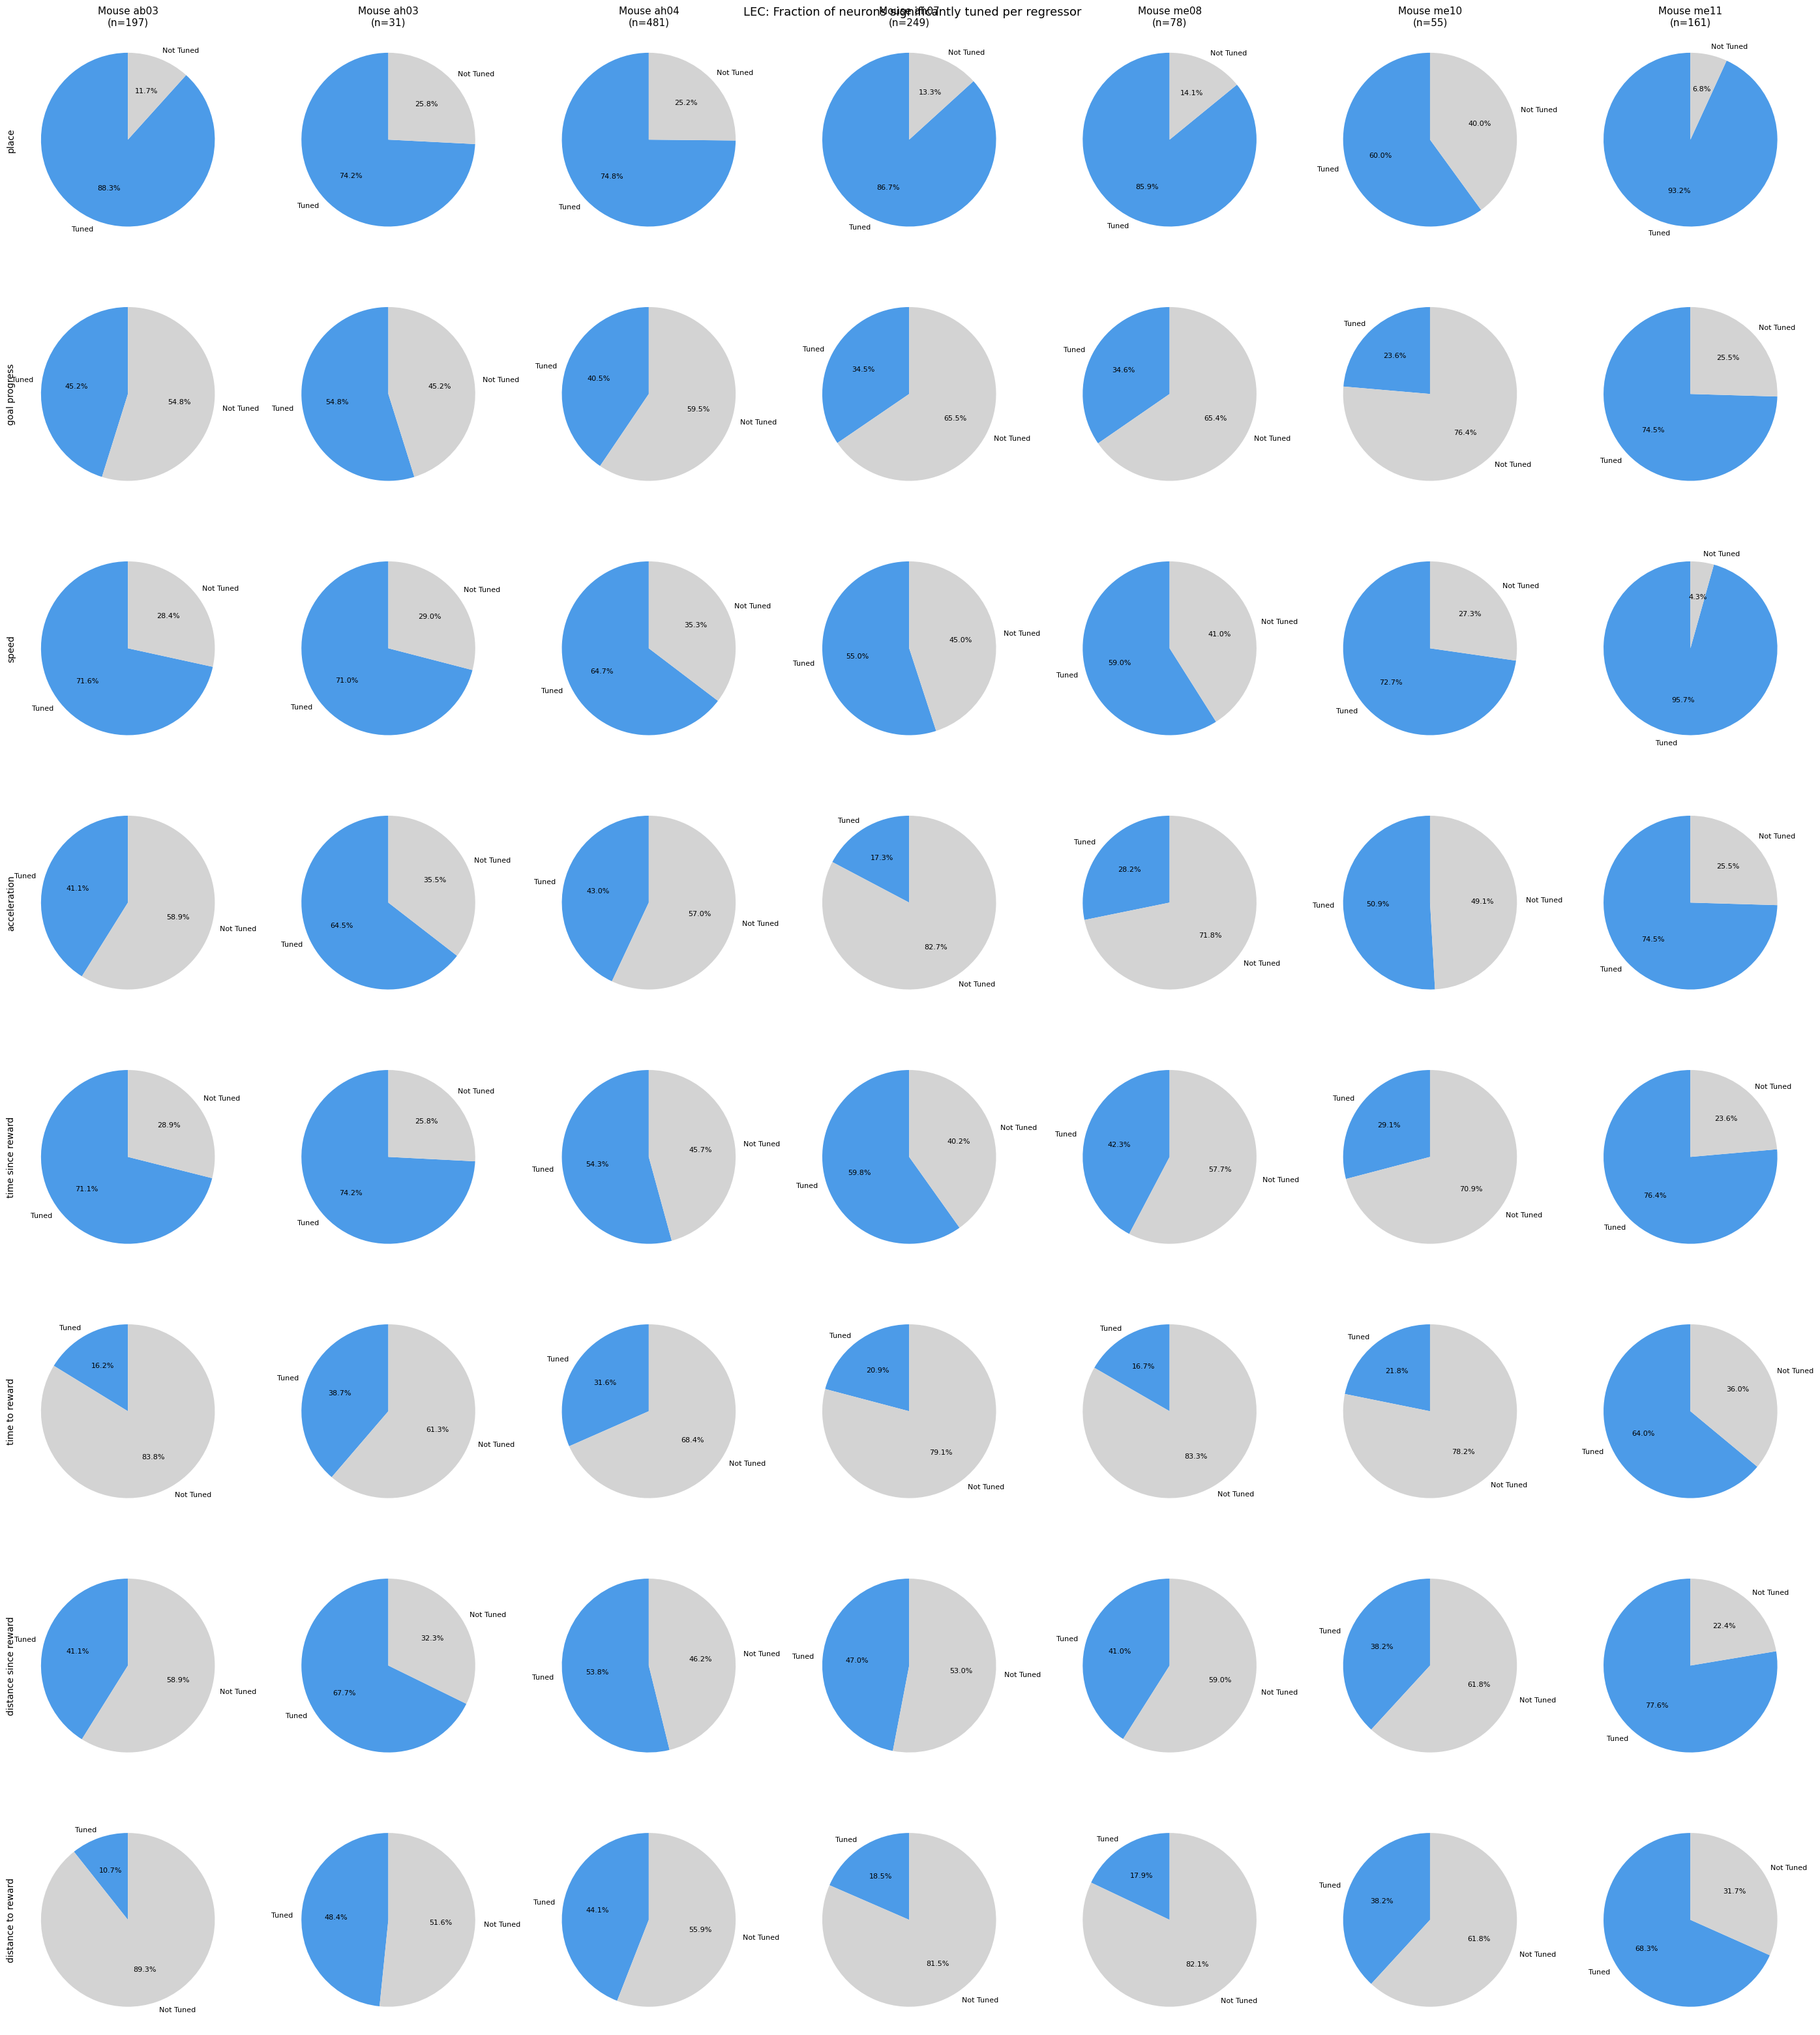

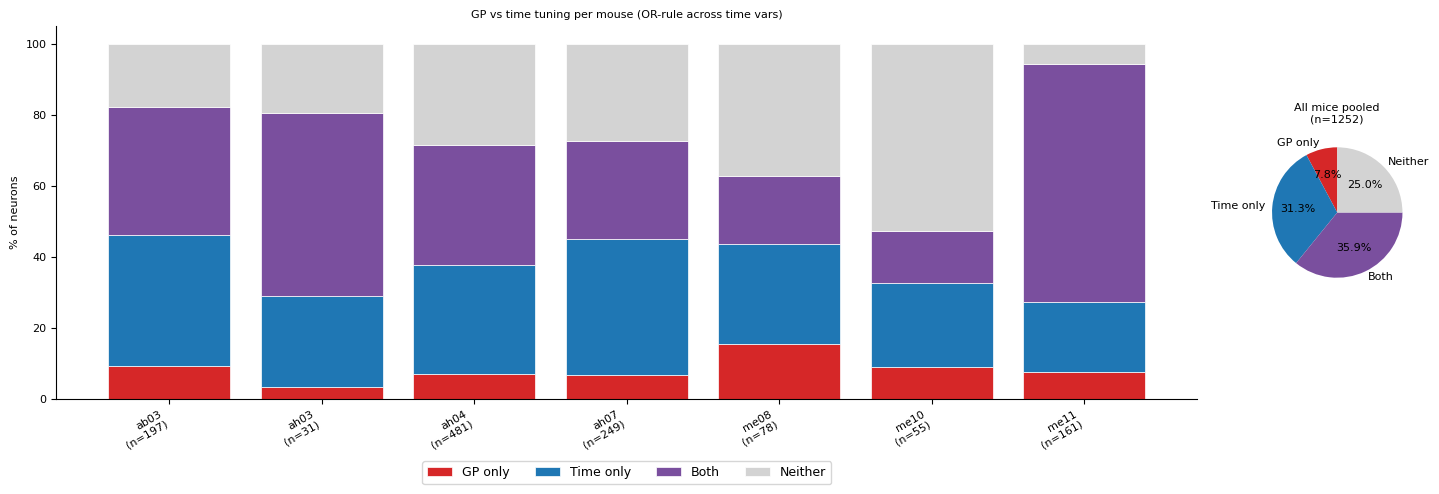

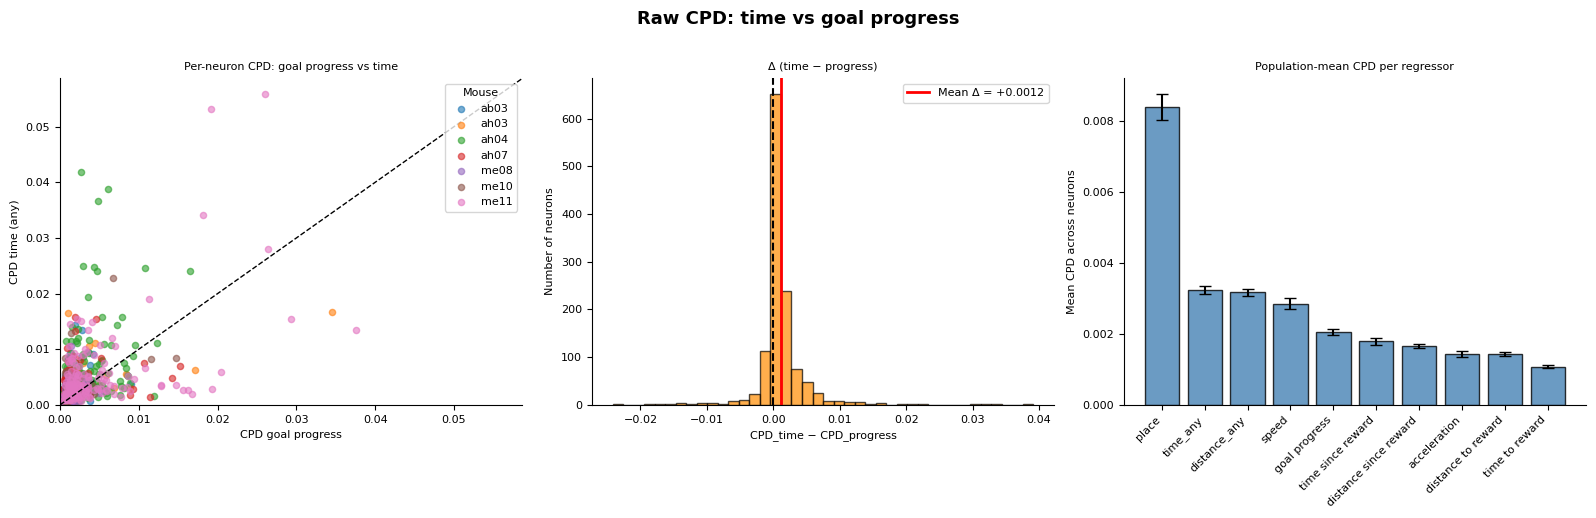

(array([0.00106214, 0.00057431, 0.00085615, ..., 0.00117557, 0.00280466,
        0.00358788]),
 array([0.00137903, 0.00172897, 0.00062435, ..., 0.0021769 , 0.00365209,
        0.00223799]))

In [47]:
GLM_results_gp20, Permutation_results_gp20, CPD_results_gp20 = run_or_load_glm(
    mouse_recdays, data_dic, SAVE_DIR, 'gp20',
    regressors_to_include=PFC_REGRESSORS,
    gp_n_bins=20,
    compute_cpd=True,
    joint_drop_groups=[
        ('time_any',     ['time_since_reward', 'time_to_reward']),
        ('distance_any', ['distance_since_reward', 'distance_to_reward']),
    ],
)
tuned_dict_gp20 = compute_tuning_arrays(
    GLM_results_gp20, Permutation_results_gp20,
    regressors_to_include=PFC_REGRESSORS, gp_n_bins=20,
)
mouse_tuning_concat_gp20 = group_tuning_by_mouse(tuned_dict_gp20)
plot_tuning_piecharts_binary(mouse_tuning_concat_gp20,
                             regressors_to_include=PFC_REGRESSORS)
plot_time_vs_progress_overlap(mouse_tuning_concat_gp20,
                              regressors_to_include=PFC_REGRESSORS)
plot_cpd_time_vs_progress(CPD_results_gp20, group_by_mouse=True)

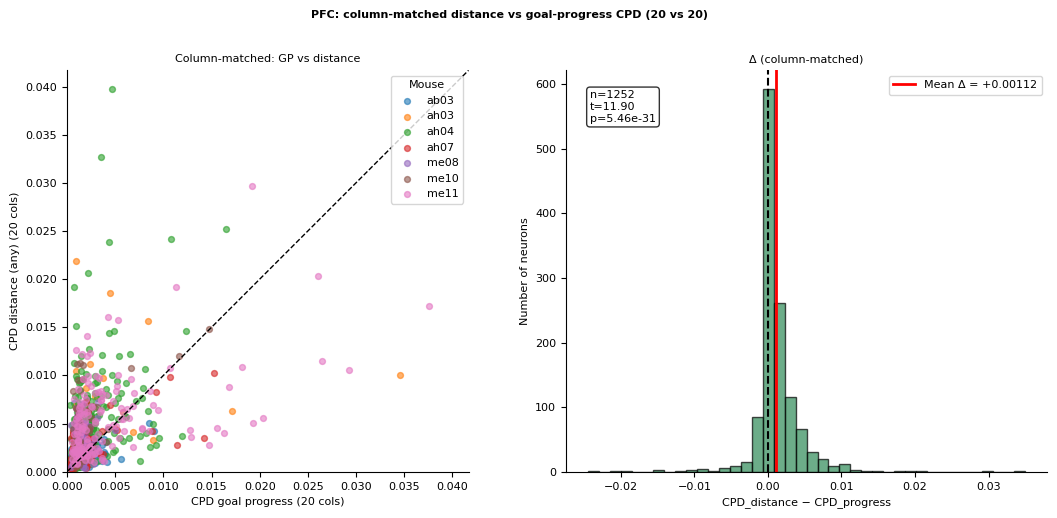

save_section('gp20'): wrote 2 file(s) to ../glm_outputs/PFC


['../glm_outputs/PFC/gp20__tuned_dict.pkl',
 '../glm_outputs/PFC/gp20__mouse_tuning_concat.pkl']

In [48]:
# Column-matched distance: GP(20 cols) vs distance_any(20 cols)
gp_cpd, da_cpd, mouse_tag = [], [], []
for mr, neuron_dict in CPD_results_gp20.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        g = cpd.get('goal_progress', np.nan)
        d = cpd.get('distance_any', np.nan)
        if np.isfinite(g) and np.isfinite(d):
            gp_cpd.append(g); da_cpd.append(d); mouse_tag.append(mouse)
gp_cpd = np.array(gp_cpd); da_cpd = np.array(da_cpd); mouse_tag = np.array(mouse_tag)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
for i, mouse in enumerate(sorted(np.unique(mouse_tag))):
    msk = mouse_tag == mouse
    ax.scatter(gp_cpd[msk], da_cpd[msk], alpha=0.6, s=18,
               color=plt.get_cmap('tab10')(i % 10), label=mouse)
lim = max(0.001, max(gp_cpd.max(), da_cpd.max()) * 1.05)
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
ax.set_xlabel('CPD goal progress (20 cols)')
ax.set_ylabel('CPD distance (any) (20 cols)')
ax.set_title('Column-matched: GP vs distance')
ax.legend(fontsize=8, title='Mouse')

ax = axes[1]
d = da_cpd - gp_cpd
ax.hist(d, bins=40, color='seagreen', alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(d.mean(), color='red', lw=2, label=f'Mean Δ = {d.mean():+.5f}')
tval, pval = st.ttest_1samp(d, 0)
ax.text(0.05, 0.95, f'n={len(d)}\nt={tval:.2f}\np={pval:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('CPD_distance − CPD_progress')
ax.set_ylabel('Number of neurons')
ax.set_title('Δ (column-matched)')
ax.legend()
plt.suptitle('PFC: column-matched distance vs goal-progress CPD (20 vs 20)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

save_section('gp20', SAVE_DIR,
             results={'tuned_dict': tuned_dict_gp20,
                      'mouse_tuning_concat': mouse_tuning_concat_gp20},
             fig_names=['pies', 'overlap', 'cpd_time', 'cpd_distance'])


## Reference-coded sanity check

Re-fits one recday under the textbook reference coding (intercept + drop first
bin of each block) and asserts that R², CPD, and ΔR² match the default
no-intercept all-bins fit to numerical precision. F-stats differ by a constant
df-scaling but the substantive significance flags agree.

In [49]:
mr_check = mouse_recdays[0]
data_check = {mr_check: data_dic[mr_check]}
np.random.seed(42)
GA, PA, CA = run_or_load_glm(
    [mr_check], data_check, SAVE_DIR, 'ref_coded_check_allbins', regressors_to_include=PFC_REGRESSORS,
    compute_cpd=True,
    joint_drop_groups=[('time_any', ['time_since_reward', 'time_to_reward'])],
)
np.random.seed(42)
GR, PR, CR = run_or_load_glm(
    [mr_check], data_check, SAVE_DIR, 'ref_coded_check_refcoded', regressors_to_include=PFC_REGRESSORS,
    compute_cpd=True,
    joint_drop_groups=[('time_any', ['time_since_reward', 'time_to_reward'])],
    parameterization='reference_coded',
)

nids = sorted(set(CA[mr_check].keys()) & set(CR[mr_check].keys()))
r2_diffs, cpd_diffs, dr2_diffs = [], {}, {}
for nid in nids:
    a, r = CA[mr_check][nid], CR[mr_check][nid]
    r2_diffs.append(abs(a['__r2_full__'] - r['__r2_full__']))
    for k in a:
        if k.startswith('__') or k not in r: continue
        cpd_diffs.setdefault(k, []).append(abs(a[k] - r[k]))
        dr2_diffs.setdefault(k, []).append(abs(a['__delta_r2__'][k] - r['__delta_r2__'][k]))

print(f'Comparing {len(nids)} neurons in {mr_check}')
print(f'max |Δ r2_full|       = {max(r2_diffs):.2e}')
print(f'max |Δ CPD| (any reg) = {max(max(v) for v in cpd_diffs.values()):.2e}')
print(f'max |Δ ΔR²| (any reg) = {max(max(v) for v in dr2_diffs.values()):.2e}')
assert max(r2_diffs) < 1e-8
assert max(max(v) for v in cpd_diffs.values()) < 1e-8
assert max(max(v) for v in dr2_diffs.values()) < 1e-8

ta = compute_tuning_arrays(GA, PA, regressors_to_include=PFC_REGRESSORS)
tr = compute_tuning_arrays(GR, PR, regressors_to_include=PFC_REGRESSORS,
                           parameterization='reference_coded')
agree = int(np.sum(ta[mr_check] == tr[mr_check]))
total = int(ta[mr_check].size)
print(f'tuning-flag agreement: {agree}/{total}  ({100*agree/total:.1f}%)')
print('PFC sanity check PASSED — parameterization-invariant.')

save_section('ref_coded_check', SAVE_DIR,
             results={'agreement_summary': {
                 'n_neurons_compared': len(nids),
                 'tuning_agreement_pct': 100 * agree / total,
             }})


run_or_load_glm('ref_coded_check_allbins'): no cache (or force_refit) — fitting


Processing recording days:   0%|          | 0/1 [00:00<?, ?it/s]


ab03_01092023_02092023


/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/code/glm_analysis_v2.py:881: RuntimeWarning: invalid value encountered in cast
  'speed':                Sp_enc,


  Design matrix: 26462 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


...

Processing recording days:   0%|          | 0/1 [00:00<?, ?it/s]


ab03_01092023_02092023
  Design matrix: 26462 rows × 84 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=reference_coded)


Processing recording days: 100%|██████████| 1/1 [01:23<00:00, 83.29s/it]

run_or_load_glm('ref_coded_check_refcoded'): saved 3 pickle(s) to ../glm_outputs/PFC
Comparing 63 neurons in ab03_01092023_02092023
max |Δ r2_full|       = 2.22e-16
max |Δ CPD| (any reg) = 6.66e-16
max |Δ ΔR²| (any reg) = 6.35e-16
ab03_01092023_02092023: tuning array shape = (63, 8)
ab03_01092023_02092023: tuning array shape = (63, 8)
tuning-flag agreement: 454/504  (90.1%)
PFC sanity check PASSED — parameterization-invariant.
save_section('ref_coded_check'): wrote 1 file(s) to ../glm_outputs/PFC


['../glm_outputs/PFC/ref_coded_check__agreement_summary.pkl']

## Goal progress: time vs distance

Adds a new optional regressor `goal_progress_distance` — the path-length
analogue of the existing time-based `goal_progress`. For each timepoint, it's
`dist_from_reward / (dist_from_reward + dist_to_reward)` — the fraction of the
total inter-reward path the animal has traveled. Same binning, same
`gp_n_bins`, same role in the design matrix as time-GP.

If both flavours carry unique CPD, it's evidence that the goal-progress signal
isn't purely temporal — neurons encode "how far along" in both clock-time and
path-length senses. If one carries CPD and the other doesn't, the dominant
flavour identifies which scale matters. Because the two share `gp_n_bins`, the
per-regressor CPD comparison is column-matched (10 vs 10) by construction.

In [53]:
# Refit with `goal_progress_distance` opted in (the distance-based progress
# regressor lives in the module's _OPTIONAL_REGRESSORS list — not in the
# default analysis_regressor_names — so existing cells above are unchanged.)

reload(glm_analysis_v2)
from glm_analysis_v2 import (
    run_glm_analysis, compute_tuning_arrays, group_tuning_by_mouse,
    plot_tuning_piecharts_binary, plot_cpd_time_vs_progress,
)

PFC_GP_DIST = ['place', 'goal_progress', 'speed', 'acceleration', 'time_since_reward', 'time_to_reward', 'distance_since_reward', 'distance_to_reward', 'goal_progress_distance']

GLM_results_gpdist, Permutation_results_gpdist, CPD_results_gpdist = run_or_load_glm(
    mouse_recdays, data_dic, SAVE_DIR, 'distance_gp',
    regressors_to_include=PFC_GP_DIST,
    compute_cpd=True,
    joint_drop_groups=[
        ('time_any', ['time_since_reward', 'time_to_reward']),
        ('gp_any',   ['goal_progress',     'goal_progress_distance']),
    ],
)
print('Done. CPD includes goal_progress AND goal_progress_distance.')

run_or_load_glm('distance_gp'): no cache (or force_refit) — fitting


Processing recording days:   0%|          | 0/25 [00:00<?, ?it/s]


ab03_01092023_02092023


/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/code/glm_analysis_v2.py:881: RuntimeWarning: invalid value encountered in cast
  'speed':                Sp_enc,


  Design matrix: 26462 rows × 101 cols (regressors: ['place', 'goal_progress', 'goal_progress_distance', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


...


me11_09122021_10122021
  Design matrix: 27028 rows × 101 cols (regressors: ['place', 'goal_progress', 'goal_progress_distance', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  96%|█████████▌| 24/25 [33:31<00:51, 51.93s/it]


me11_12122021_13122021
  Design matrix: 24771 rows × 101 cols (regressors: ['place', 'goal_progress', 'goal_progress_distance', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days: 100%|██████████| 25/25 [33:50<00:00, 81.24s/it]

run_or_load_glm('distance_gp'): saved 3 pickle(s) to ../glm_outputs/PFC
Done. CPD includes goal_progress AND goal_progress_distance.


ab03_01092023_02092023: tuning array shape = (63, 9)
ab03_05092023_06092023: tuning array shape = (64, 9)
ab03_29082023_30082023: tuning array shape = (70, 9)
ah03_12082021_13082021: tuning array shape = (16, 9)
ah03_18082021_19082021: tuning array shape = (15, 9)
ah04_01122021_02122021: tuning array shape = (117, 9)
ah04_05122021_06122021: tuning array shape = (114, 9)
ah04_07122021_08122021: tuning array shape = (81, 9)
ah04_09122021_10122021: tuning array shape = (99, 9)
ah04_14122021_16122021: tuning array shape = (70, 9)
ah07_01092023_02092023: tuning array shape = (97, 9)
ah07_27082023_28082023: tuning array shape = (80, 9)
ah07_29082023_30082023: tuning array shape = (72, 9)
me08_06092021_09092021: tuning array shape = (23, 9)
me08_10092021_11092021: tuning array shape = (32, 9)
me08_12092021_13092021: tuning array shape = (23, 9)
me10_09122021_10122021: tuning array shape = (28, 9)
me10_14122021_15122021: tuning array shape = (20, 9)
me10_17122021_19122021: tuning array shape =

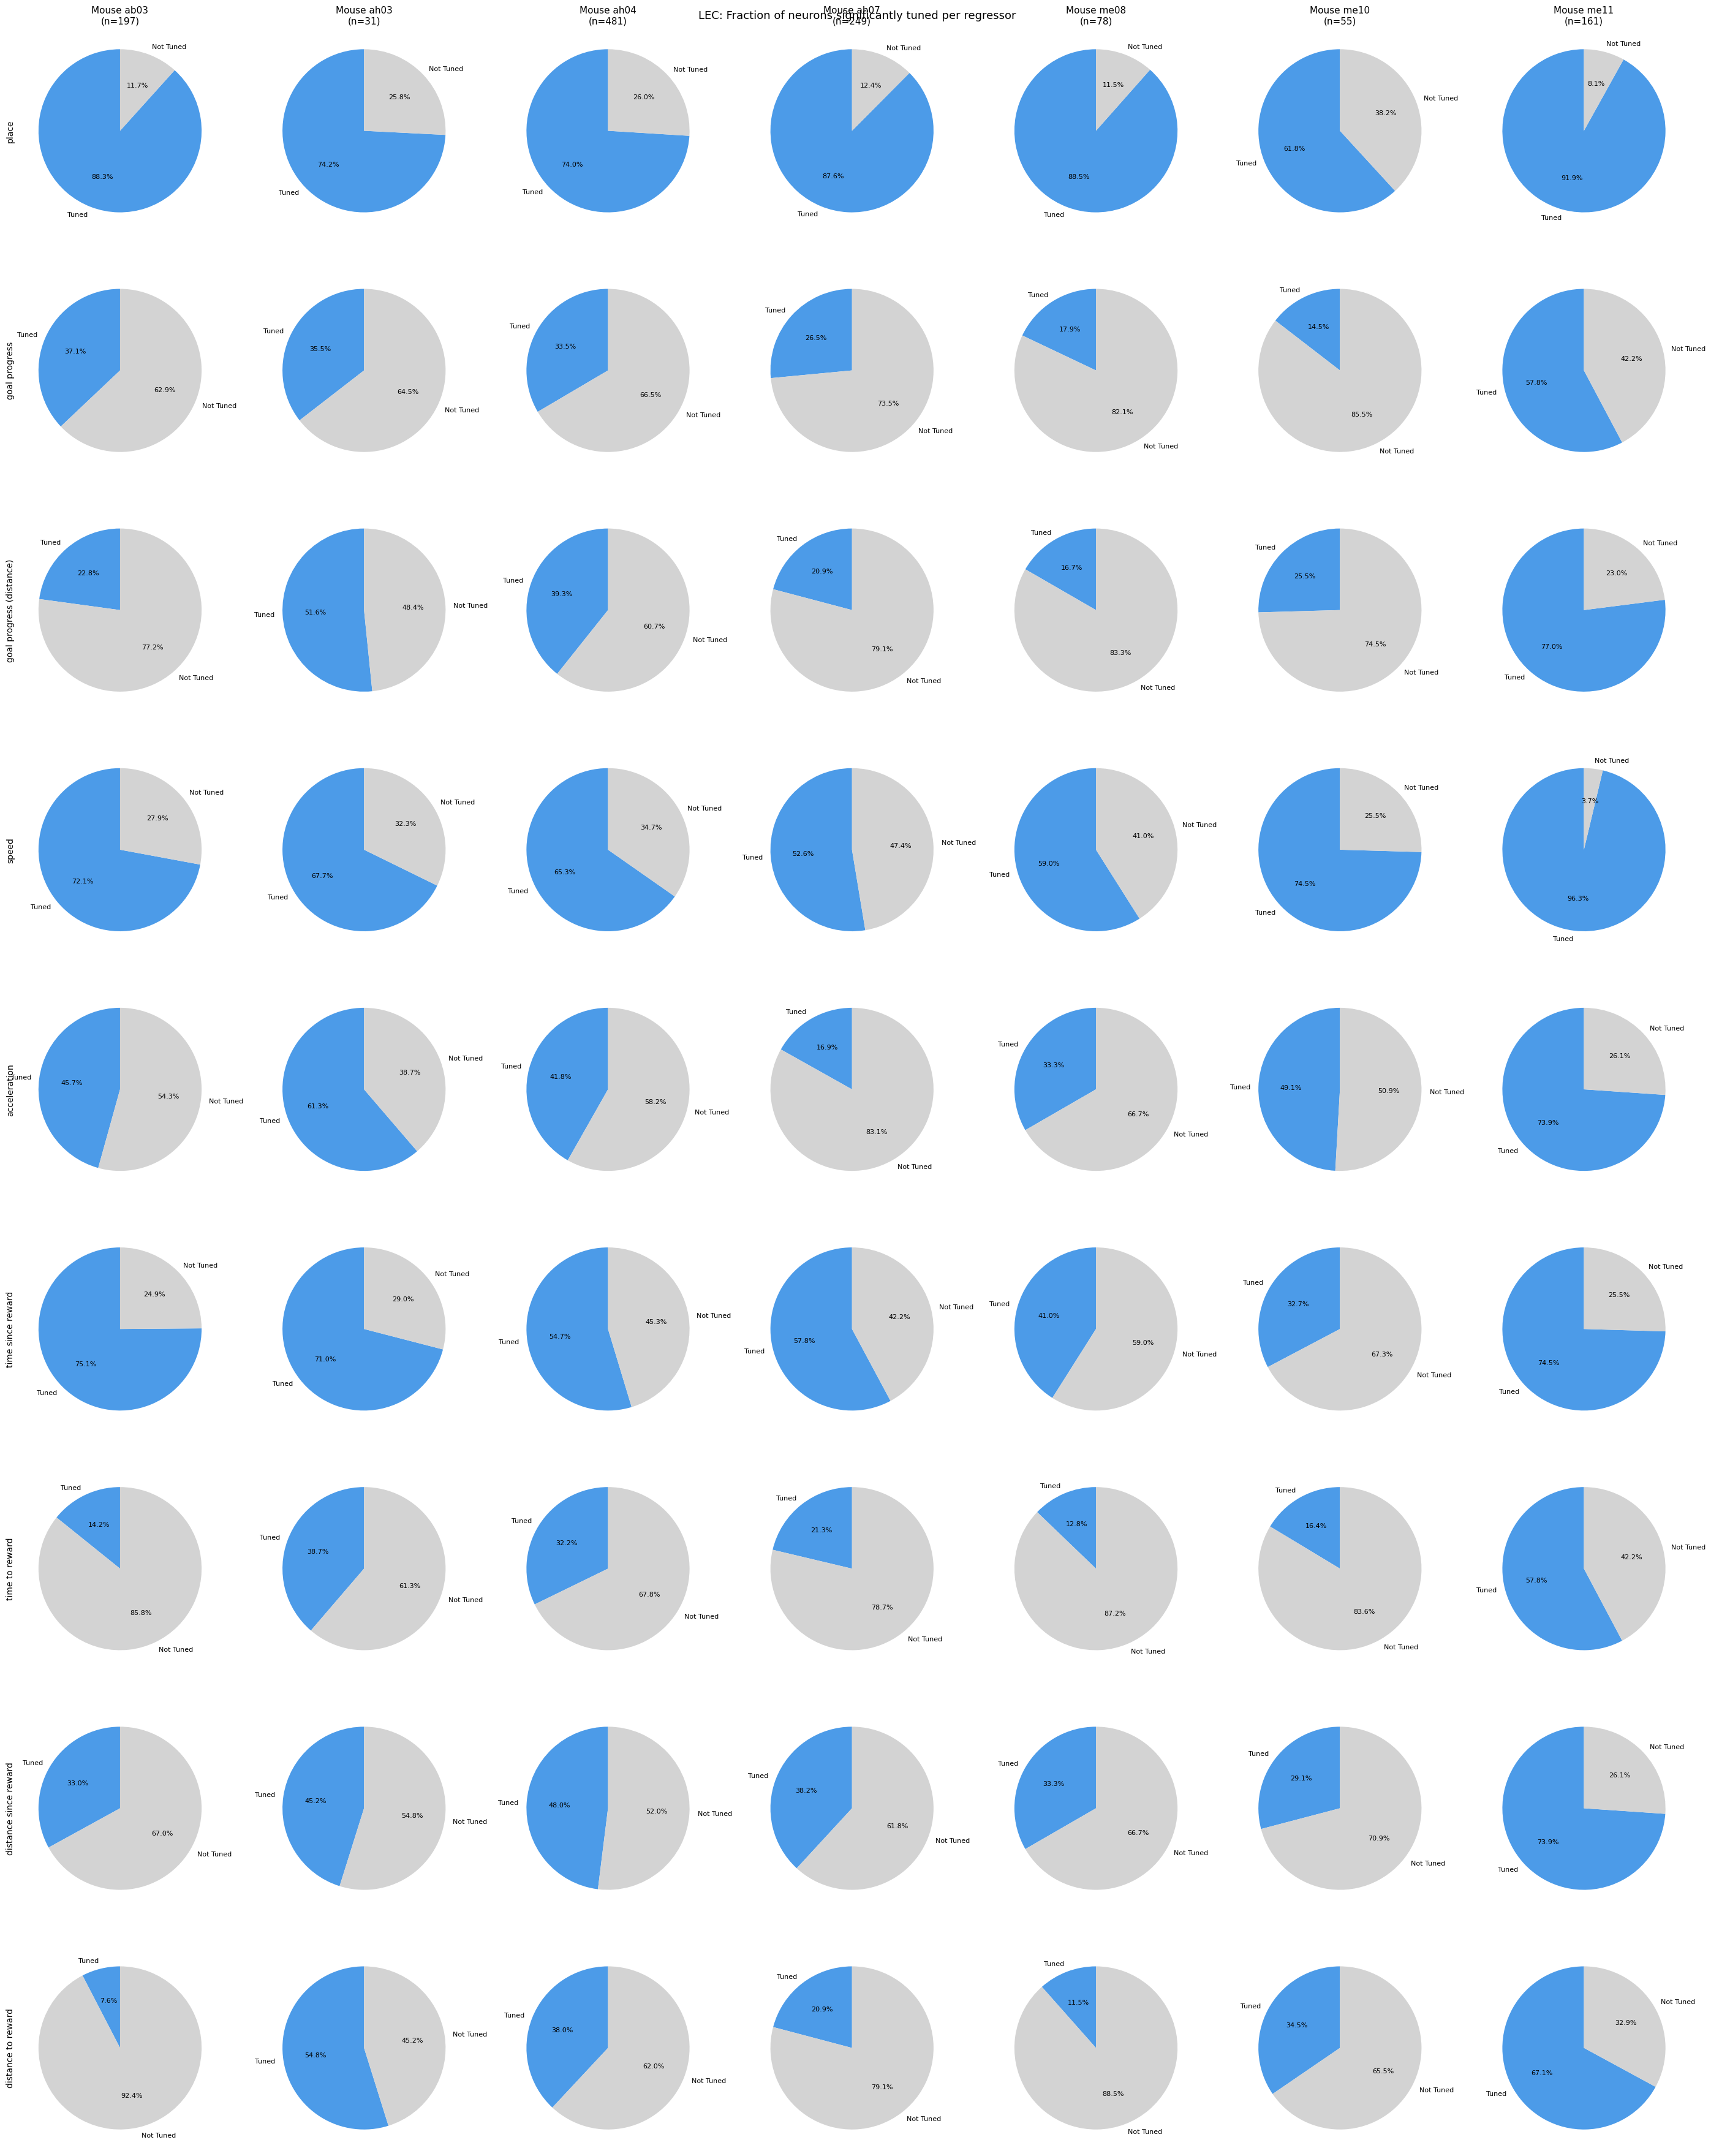

In [54]:
tuned_dict_gpdist = compute_tuning_arrays(
    GLM_results_gpdist, Permutation_results_gpdist,
    regressors_to_include=PFC_GP_DIST,
)
mouse_tuning_concat_gpdist = group_tuning_by_mouse(tuned_dict_gpdist)
plot_tuning_piecharts_binary(mouse_tuning_concat_gpdist,
                             regressors_to_include=PFC_GP_DIST)

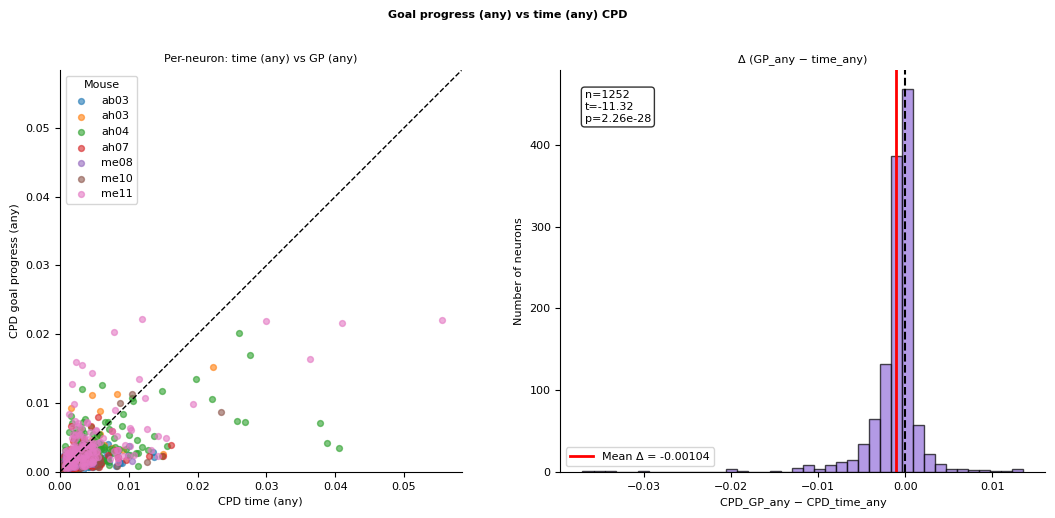

Per-mouse mean Δ (CPD_GP_any − CPD_time_any):
  ab03: μ=-0.00148  n=197
  ah03: μ=-0.00074  n=31
  ah04: μ=-0.00098  n=481
  ah07: μ=-0.00107  n=249
  me08: μ=-0.00064  n=78
  me10: μ=-0.00120  n=55
  me11: μ=-0.00084  n=161


In [55]:
# Per-neuron CPD: time (any) vs goal_progress (any) using joint groups.
t_any, gp_any, mouse_tag = [], [], []
for mr, neuron_dict in CPD_results_gpdist.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        a = cpd.get('time_any', np.nan)
        b = cpd.get('gp_any',   np.nan)
        if np.isfinite(a) and np.isfinite(b):
            t_any.append(a); gp_any.append(b); mouse_tag.append(mouse)
t_any = np.array(t_any); gp_any = np.array(gp_any); mouse_tag = np.array(mouse_tag)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
for i, mouse in enumerate(sorted(np.unique(mouse_tag))):
    msk = mouse_tag == mouse
    ax.scatter(t_any[msk], gp_any[msk], alpha=0.6, s=18,
               color=plt.get_cmap('tab10')(i % 10), label=mouse)
lim = max(0.001, max(t_any.max(), gp_any.max()) * 1.05)
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
ax.set_xlabel('CPD time (any)')
ax.set_ylabel('CPD goal progress (any)')
ax.set_title('Per-neuron: time (any) vs GP (any)')
ax.legend(fontsize=8, title='Mouse')

ax = axes[1]
d = gp_any - t_any
ax.hist(d, bins=40, color='mediumpurple', alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(d.mean(), color='red', lw=2, label=f'Mean Δ = {d.mean():+.5f}')
tval, pval = st.ttest_1samp(d, 0)
ax.text(0.05, 0.95, f'n={len(d)}\nt={tval:.2f}\np={pval:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('CPD_GP_any − CPD_time_any')
ax.set_ylabel('Number of neurons')
ax.set_title('Δ (GP_any − time_any)')
ax.legend()
plt.suptitle('Goal progress (any) vs time (any) CPD',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Per-mouse paired test
from collections import defaultdict
by_mouse_diff = defaultdict(list)
for mr, neuron_dict in CPD_results_gpdist.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        a = cpd.get('time_any', np.nan)
        b = cpd.get('gp_any',   np.nan)
        if np.isfinite(a) and np.isfinite(b):
            by_mouse_diff[mouse].append(b - a)
print('Per-mouse mean Δ (CPD_GP_any − CPD_time_any):')
for mouse in sorted(by_mouse_diff.keys()):
    diffs = np.array(by_mouse_diff[mouse])
    print(f'  {mouse}: μ={diffs.mean():+.5f}  n={len(diffs)}')


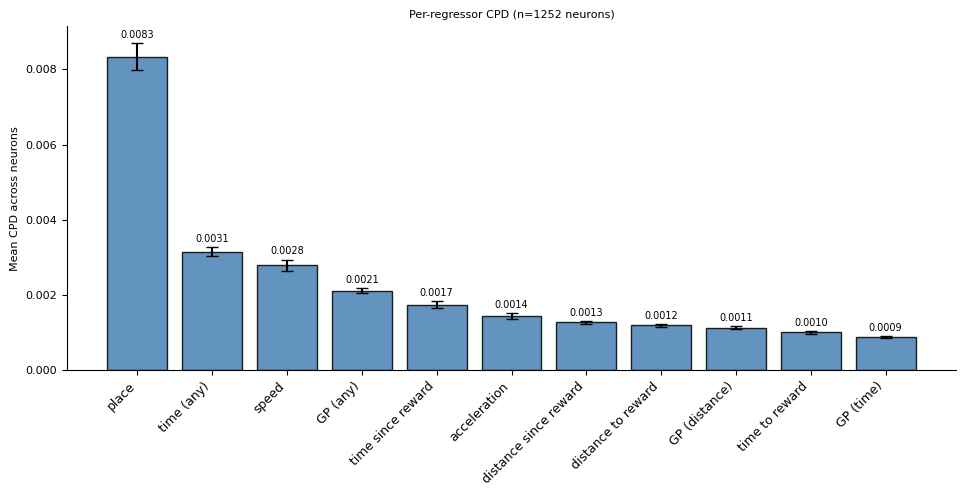

regressor                    mean CPD         sem   n_neurons
place                         0.00834     0.00037        1252
time (any)                    0.00314     0.00012        1252
speed                         0.00279     0.00015        1252
GP (any)                      0.00210     0.00007        1252
time since reward             0.00174     0.00009        1252
acceleration                  0.00143     0.00008        1252
distance since reward         0.00127     0.00004        1252
distance to reward            0.00119     0.00004        1252
GP (distance)                 0.00112     0.00004        1252
time to reward                0.00100     0.00004        1252
GP (time)                     0.00088     0.00003        1252


In [58]:
# Mean CPD per regressor group, across all neurons in CPD_results_gpdist.
from collections import defaultdict

# Pool CPD values per regressor key, skipping reserved (__-prefixed) bookkeeping keys.
cpd_by_reg = defaultdict(list)
for mr, neuron_dict in CPD_results_gpdist.items():
    for cpd in neuron_dict.values():
        for reg, val in cpd.items():
            if reg.startswith('__'):
                continue
            if np.isfinite(val):
                cpd_by_reg[reg].append(val)

# Sort regressors by mean CPD (descending) for a readable bar chart.
regs   = sorted(cpd_by_reg.keys(), key=lambda r: -np.mean(cpd_by_reg[r]))
means  = [np.mean(cpd_by_reg[r])                            for r in regs]
sems   = [np.std(cpd_by_reg[r]) / np.sqrt(len(cpd_by_reg[r])) for r in regs]
counts = [len(cpd_by_reg[r])                                for r in regs]

# Pretty display names (matches the module's labels).
display = {
    'place':                  'place',
    'head_direction':         'head direction',
    'goal_progress':          'GP (time)',
    'goal_progress_distance': 'GP (distance)',
    'gp_any':                 'GP (any)',
    'speed':                  'speed',
    'acceleration':           'acceleration',
    'time_from_reward':       'time since reward',
    'time_to_reward':         'time to reward',
    'time_any':               'time (any)',
    'distance_from_reward':   'distance since reward',
    'distance_to_reward':     'distance to reward',
}

fig, ax = plt.subplots(figsize=(max(8, 0.7 * len(regs) + 2), 5))
xs = np.arange(len(regs))
ax.bar(xs, means, yerr=sems, color='steelblue', alpha=0.85,
       edgecolor='black', capsize=4)
ax.set_xticks(xs)
ax.set_xticklabels([display.get(r, r) for r in regs], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean CPD across neurons')
ax.set_title(f'Per-regressor CPD (n={counts[0]} neurons)')
ax.axhline(0, color='black', lw=0.5)

# Optional: annotate each bar with mean ± sem
for x, m, s in zip(xs, means, sems):
    ax.text(x, m + s + max(means) * 0.01, f'{m:.4f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout(); plt.show()

# Print numerical summary
print(f'{"regressor":25s}  {"mean CPD":>10s}  {"sem":>10s}  {"n_neurons":>10s}')
for r, m, s, c in zip(regs, means, sems, counts):
    print(f'{display.get(r, r):25s}  {m:>10.5f}  {s:>10.5f}  {c:>10d}')


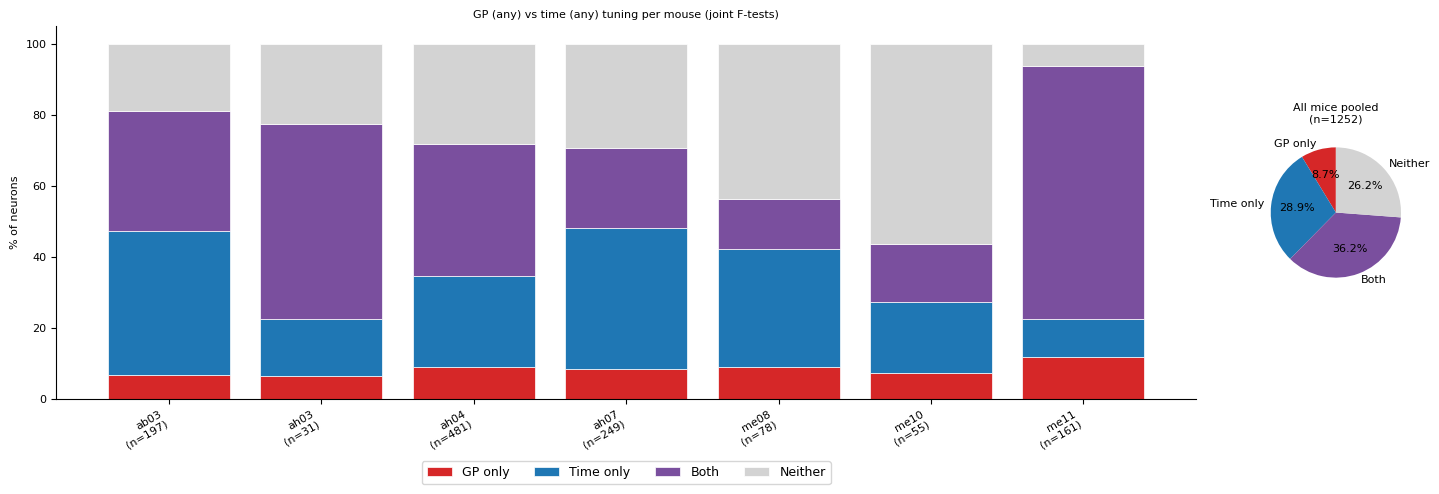

In [56]:
# GP (any) vs time (any) tuning overlap, based on the joint F-tests from the refit.
# Significance: F_real > 95th percentile of F_perm (same rule used by compute_tuning_arrays).
from collections import defaultdict

per_mouse = defaultdict(lambda: np.zeros(4, dtype=int))  # [GP only, Time only, Both, Neither]

for mr, neuron_dict in Permutation_results_gpdist.items():
    mouse = mr.split('_')[0]
    for (F_real, F_perm) in neuron_dict.values():
        gp_f = F_real.get('gp_any');   gp_p = F_perm.get('gp_any')
        t_f  = F_real.get('time_any'); t_p  = F_perm.get('time_any')
        if gp_f is None or t_f is None or gp_p is None or t_p is None:
            continue
        gp_sig = gp_f > np.percentile(gp_p, 95)
        t_sig  = t_f  > np.percentile(t_p,  95)
        if   gp_sig and not t_sig: per_mouse[mouse][0] += 1
        elif t_sig and not gp_sig: per_mouse[mouse][1] += 1
        elif gp_sig and t_sig:     per_mouse[mouse][2] += 1
        else:                       per_mouse[mouse][3] += 1

mouse_ids  = sorted(per_mouse.keys())
n_mice     = len(mouse_ids)
totals     = np.array([per_mouse[m].sum() for m in mouse_ids])
agg_counts = sum(per_mouse[m] for m in mouse_ids)

cat_labels = ['GP only', 'Time only', 'Both', 'Neither']
cat_colors = ['#d62728', '#1f77b4', '#7a4f9e', '#d3d3d3']

fig, axes = plt.subplots(1, 2, figsize=(max(8, 1.5 * n_mice + 4), 5),
                         gridspec_kw={'width_ratios': [n_mice, 1]})

ax = axes[0]
bar_bottom = np.zeros(n_mice)
for k, (lbl, c) in enumerate(zip(cat_labels, cat_colors)):
    counts_k = np.array([per_mouse[m][k] for m in mouse_ids])
    pcts = 100 * counts_k / np.where(totals > 0, totals, 1)
    ax.bar(np.arange(n_mice), pcts, bottom=bar_bottom,
           color=c, edgecolor='white', linewidth=0.5, label=lbl)
    bar_bottom += pcts
ax.set_xticks(np.arange(n_mice))
ax.set_xticklabels([f'{m}\n(n={t})' for m, t in zip(mouse_ids, totals)],
                   rotation=30, ha='right', fontsize=8)
ax.set_ylabel('% of neurons')
ax.set_ylim(0, 105)
ax.set_title('GP (any) vs time (any) tuning per mouse (joint F-tests)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=9)

ax = axes[1]
nonzero = [(c, l, col) for c, l, col in zip(agg_counts, cat_labels, cat_colors) if c > 0]
if nonzero:
    sizes_, labels_, colors_ = zip(*nonzero)
    ax.pie(sizes_, labels=labels_, autopct='%1.1f%%', startangle=90, colors=colors_)
total_agg = int(agg_counts.sum())
ax.set_title(f'All mice pooled\n(n={total_agg})')

plt.tight_layout(); plt.show()


In [59]:
from glm_analysis_v2 import _resolve_regressor_groups
groups, names = _resolve_regressor_groups(PFC_GP_DIST)
for name in names:
    print(f'  {name:25s}  {len(groups[name]):>3d} cols')
print()
print('  Joint groups (from joint_drop_groups):')
print(f"  {'time_any':25s}  {len(groups['time_from_reward']) + len(groups['time_to_reward']):>3d} cols")
print(f"  {'gp_any':25s}  {len(groups['goal_progress']) + len(groups['goal_progress_distance']):>3d} cols")


  place                       21 cols
  goal_progress               10 cols
  goal_progress_distance      10 cols
  speed                       10 cols
  acceleration                10 cols
  time_from_reward            10 cols
  time_to_reward              10 cols
  distance_from_reward        10 cols
  distance_to_reward          10 cols

  Joint groups (from joint_drop_groups):
  time_any                    20 cols
  gp_any                      20 cols


1252 neurons × 10 GP bins


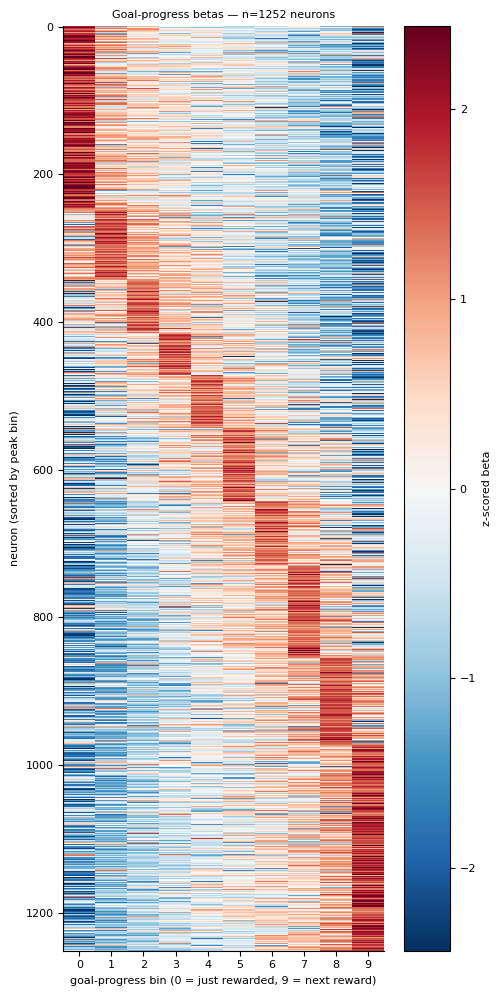

In [60]:
from glm_analysis_v2 import _resolve_regressor_groups

# Get column indices of the goal_progress block (10 bins for this fit).
groups, _ = _resolve_regressor_groups(PFC_GP_DIST)
gp_cols = groups['goal_progress']

# Collect goal_progress betas for every fitted neuron.
all_betas = []
for mr, neuron_dict in GLM_results_gpdist.items():
    for nidx, beta in neuron_dict.items():
        all_betas.append(beta[gp_cols])
all_betas = np.array(all_betas)   # (n_neurons, n_gp_bins)
print(f'{all_betas.shape[0]} neurons × {all_betas.shape[1]} GP bins')

# Sort by index of peak beta (argmax).
peak_idx   = np.argmax(all_betas, axis=1)
sort_order = np.argsort(peak_idx)
sorted_betas = all_betas[sort_order]

# Z-score each neuron so all rows are on the same colour scale.
sorted_z = (sorted_betas - sorted_betas.mean(axis=1, keepdims=True)) / \
           (sorted_betas.std(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(5, 10))
vmax = np.percentile(np.abs(sorted_z), 99)
im = ax.imshow(sorted_z, aspect='auto', cmap='RdBu_r',
               vmin=-vmax, vmax=vmax, interpolation='nearest')
ax.set_xlabel('goal-progress bin (0 = just rewarded, 9 = next reward)')
ax.set_ylabel('neuron (sorted by peak bin)')
ax.set_title(f'Goal-progress betas — n={sorted_z.shape[0]} neurons')
ax.set_xticks(np.arange(sorted_z.shape[1]))
plt.colorbar(im, ax=ax, label='z-scored beta')
plt.tight_layout(); plt.show()


1252 neurons × 10 GP bins


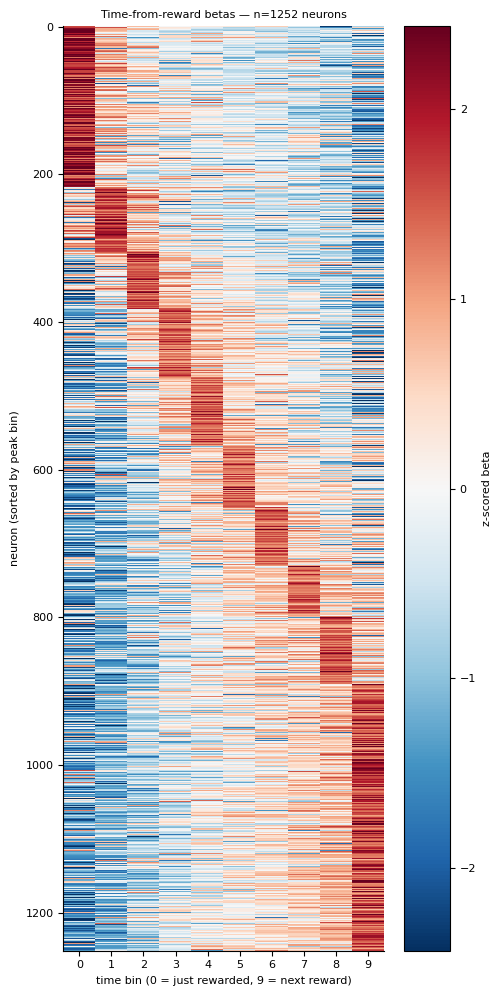

In [61]:
from glm_analysis_v2 import _resolve_regressor_groups

# Get column indices of the goal_progress block (10 bins for this fit).
groups, _ = _resolve_regressor_groups(PFC_GP_DIST)
gp_cols = groups['time_from_reward']

# Collect time_from_reward betas for every fitted neuron.
all_betas = []
for mr, neuron_dict in GLM_results_gpdist.items():
    for nidx, beta in neuron_dict.items():
        all_betas.append(beta[gp_cols])
all_betas = np.array(all_betas)   # (n_neurons, n_gp_bins)
print(f'{all_betas.shape[0]} neurons × {all_betas.shape[1]} GP bins')

# Sort by index of peak beta (argmax).
peak_idx   = np.argmax(all_betas, axis=1)
sort_order = np.argsort(peak_idx)
sorted_betas = all_betas[sort_order]

# Z-score each neuron so all rows are on the same colour scale.
sorted_z = (sorted_betas - sorted_betas.mean(axis=1, keepdims=True)) / \
           (sorted_betas.std(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(5, 10))
vmax = np.percentile(np.abs(sorted_z), 99)
im = ax.imshow(sorted_z, aspect='auto', cmap='RdBu_r',
               vmin=-vmax, vmax=vmax, interpolation='nearest')
ax.set_xlabel('time bin (0 = just rewarded, 9 = next reward)')
ax.set_ylabel('neuron (sorted by peak bin)')
ax.set_title(f'Time-from-reward betas — n={sorted_z.shape[0]} neurons')
ax.set_xticks(np.arange(sorted_z.shape[1]))
plt.colorbar(im, ax=ax, label='z-scored beta')
plt.tight_layout(); plt.show()


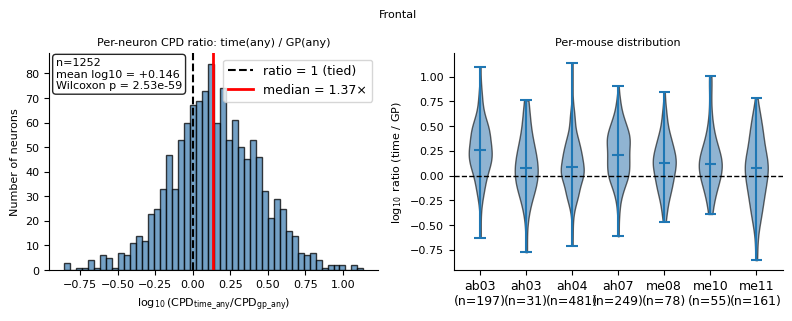

Total neurons compared:      1252
  time_any > gp_any:         876  (70.0%)
  gp_any > time_any:         376  (30.0%)
  median ratio (time/GP):    1.370×


In [67]:
# Per-neuron CPD ratio: time_any / gp_any (log scale to handle wide spread).
import numpy as np

ratios, mouse_tag = [], []
for mr, neuron_dict in CPD_results_gpdist.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        t = cpd.get('time_any', np.nan)
        g = cpd.get('gp_any',   np.nan)
        if np.isfinite(t) and np.isfinite(g) and t > 0 and g > 0:
            ratios.append(t / g)
            mouse_tag.append(mouse)
ratios    = np.array(ratios)
mouse_tag = np.array(mouse_tag)
log_r     = np.log10(ratios)   # +ve → time wins, -ve → GP wins

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
fig.suptitle('Frontal')
# Pooled log-ratio histogram
ax = axes[0]
ax.hist(log_r, bins=50, color='steelblue', alpha=0.75, edgecolor='black')
ax.axvline(0, color='black', ls='--', lw=1.5, label='ratio = 1 (tied)')
ax.axvline(np.median(log_r), color='red', lw=2,
           label=f'median = {10**np.median(log_r):.2f}×')
# Wilcoxon test that the log-ratio is centred on 0 (i.e. ratio centred on 1)
w, pw = st.wilcoxon(log_r)
ax.text(0.02, 0.98, f'n={len(log_r)}\nmean log10 = {log_r.mean():+.3f}'
                    f'\nWilcoxon p = {pw:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax.set_xlabel(r'$\log_{10}(\mathrm{CPD}_{\mathrm{time\_any}} / \mathrm{CPD}_{\mathrm{gp\_any}})$')
ax.set_ylabel('Number of neurons')
ax.set_title('Per-neuron CPD ratio: time(any) / GP(any)')
ax.legend(loc='upper right', fontsize=9)
# # Helpful annotations on the axis
# ax.text(0.99, -0.10, 'GP wins ←', transform=ax.transAxes, ha='right',
#         va='top', fontsize=9, color='crimson')
# ax.text(0.99, -0.10, '          → time wins', transform=ax.transAxes,
#         ha='right', va='top', fontsize=9, color='steelblue')

# Per-mouse summary
ax = axes[1]
mice = sorted(np.unique(mouse_tag))
data = [log_r[mouse_tag == m] for m in mice]
parts = ax.violinplot(data, positions=np.arange(len(mice)), showmedians=True)
for body in parts['bodies']:
    body.set_facecolor('steelblue'); body.set_alpha(0.6); body.set_edgecolor('black')
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_xticks(np.arange(len(mice)))
ax.set_xticklabels([f'{m}\n(n={len(d)})' for m, d in zip(mice, data)], fontsize=9)
ax.set_ylabel(r'$\log_{10}$ ratio (time / GP)')
ax.set_title('Per-mouse distribution')

plt.tight_layout(); plt.show()

# Print summary
n_time   = int((log_r > 0).sum())
n_gp     = int((log_r < 0).sum())
print(f'Total neurons compared:      {len(log_r)}')
print(f'  time_any > gp_any:         {n_time}  ({100*n_time/len(log_r):.1f}%)')
print(f'  gp_any > time_any:         {n_gp}  ({100*n_gp/len(log_r):.1f}%)')
print(f'  median ratio (time/GP):    {10**np.median(log_r):.3f}×')


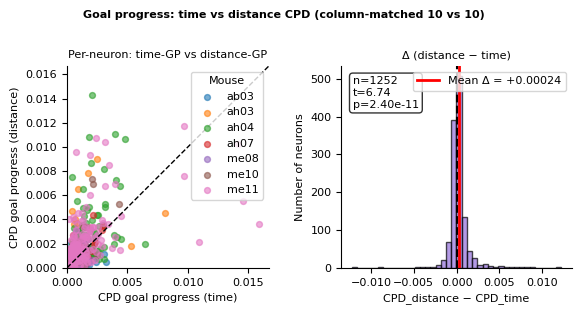

Per-mouse mean Δ (CPD_distance − CPD_time):
  ab03: μ=-0.00005  n=197
  ah03: μ=+0.00111  n=31
  ah04: μ=+0.00027  n=481
  ah07: μ=+0.00007  n=249
  me08: μ=+0.00010  n=78
  me10: μ=+0.00051  n=55
  me11: μ=+0.00059  n=161
save_section('distance_gp'): wrote 3 file(s) to ../glm_outputs/PFC


['../glm_outputs/PFC/distance_gp__tuned_dict.pkl',
 '../glm_outputs/PFC/distance_gp__mouse_tuning_concat.pkl',
 '../glm_outputs/PFC/distance_gp__by_mouse_diff.pkl']

In [ ]:
# Per-neuron CPD: time-GP vs distance-GP (column-matched, both 10 cols).
gp_t, gp_d, mouse_tag = [], [], []
for mr, neuron_dict in CPD_results_gpdist.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        a = cpd.get('goal_progress', np.nan)
        b = cpd.get('goal_progress_distance', np.nan)
        if np.isfinite(a) and np.isfinite(b):
            gp_t.append(a); gp_d.append(b); mouse_tag.append(mouse)
gp_t = np.array(gp_t); gp_d = np.array(gp_d); mouse_tag = np.array(mouse_tag)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
ax = axes[0]
for i, mouse in enumerate(sorted(np.unique(mouse_tag))):
    msk = mouse_tag == mouse
    ax.scatter(gp_t[msk], gp_d[msk], alpha=0.6, s=18,
               color=plt.get_cmap('tab10')(i % 10), label=mouse)
lim = max(0.001, max(gp_t.max(), gp_d.max()) * 1.05)
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
ax.set_xlabel('CPD goal progress (time)')
ax.set_ylabel('CPD goal progress (distance)')
ax.set_title('Per-neuron: time-GP vs distance-GP')
ax.legend(fontsize=8, title='Mouse')

ax = axes[1]
d = gp_d - gp_t
ax.hist(d, bins=40, color='mediumpurple', alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(d.mean(), color='red', lw=2, label=f'Mean Δ = {d.mean():+.5f}')
tval, pval = st.ttest_1samp(d, 0)
ax.text(0.05, 0.95, f'n={len(d)}\nt={tval:.2f}\np={pval:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('CPD_distance − CPD_time')
ax.set_ylabel('Number of neurons')
ax.set_title('Δ (distance − time)')
ax.legend()
plt.suptitle('Goal progress: time vs distance CPD (column-matched 10 vs 10)',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Per-mouse paired test
from collections import defaultdict
by_mouse_diff = defaultdict(list)
for mr, neuron_dict in CPD_results_gpdist.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        a = cpd.get('goal_progress', np.nan)
        b = cpd.get('goal_progress_distance', np.nan)
        if np.isfinite(a) and np.isfinite(b):
            by_mouse_diff[mouse].append(b - a)
print('Per-mouse mean Δ (CPD_distance − CPD_time):')
for mouse in sorted(by_mouse_diff.keys()):
    diffs = np.array(by_mouse_diff[mouse])
    print(f'  {mouse}: μ={diffs.mean():+.5f}  n={len(diffs)}')

save_section('distance_gp', SAVE_DIR,
             results={'tuned_dict': tuned_dict_gpdist,
                      'mouse_tuning_concat': mouse_tuning_concat_gpdist,
                      'by_mouse_diff': dict(by_mouse_diff)},
             fig_names=['pies', 'cpd_scatter'])


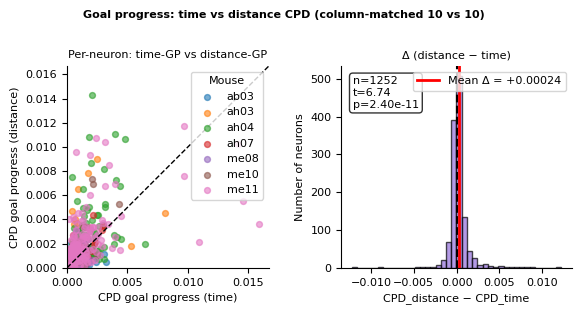

Per-mouse mean Δ (CPD_distance − CPD_time):
  ab03: μ=-0.00005  n=197
  ah03: μ=+0.00111  n=31
  ah04: μ=+0.00027  n=481
  ah07: μ=+0.00007  n=249
  me08: μ=+0.00010  n=78
  me10: μ=+0.00051  n=55
  me11: μ=+0.00059  n=161
save_section('distance_gp'): wrote 3 file(s) to ../glm_outputs/PFC


['../glm_outputs/PFC/distance_gp__tuned_dict.pkl',
 '../glm_outputs/PFC/distance_gp__mouse_tuning_concat.pkl',
 '../glm_outputs/PFC/distance_gp__by_mouse_diff.pkl']

In [51]:
# Per-neuron CPD: time-GP vs distance-GP (column-matched, both 10 cols).
gp_t, gp_d, mouse_tag = [], [], []
for mr, neuron_dict in CPD_results_gpdist.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        a = cpd.get('goal_progress', np.nan)
        b = cpd.get('goal_progress_distance', np.nan)
        if np.isfinite(a) and np.isfinite(b):
            gp_t.append(a); gp_d.append(b); mouse_tag.append(mouse)
gp_t = np.array(gp_t); gp_d = np.array(gp_d); mouse_tag = np.array(mouse_tag)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
ax = axes[0]
for i, mouse in enumerate(sorted(np.unique(mouse_tag))):
    msk = mouse_tag == mouse
    ax.scatter(gp_t[msk], gp_d[msk], alpha=0.6, s=18,
               color=plt.get_cmap('tab10')(i % 10), label=mouse)
lim = max(0.001, max(gp_t.max(), gp_d.max()) * 1.05)
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
ax.set_xlabel('CPD goal progress (time)')
ax.set_ylabel('CPD goal progress (distance)')
ax.set_title('Per-neuron: time-GP vs distance-GP')
ax.legend(fontsize=8, title='Mouse')

ax = axes[1]
d = gp_d - gp_t
ax.hist(d, bins=40, color='mediumpurple', alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(d.mean(), color='red', lw=2, label=f'Mean Δ = {d.mean():+.5f}')
tval, pval = st.ttest_1samp(d, 0)
ax.text(0.05, 0.95, f'n={len(d)}\nt={tval:.2f}\np={pval:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('CPD_distance − CPD_time')
ax.set_ylabel('Number of neurons')
ax.set_title('Δ (distance − time)')
ax.legend()
plt.suptitle('Goal progress: time vs distance CPD (column-matched 10 vs 10)',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Per-mouse paired test
from collections import defaultdict
by_mouse_diff = defaultdict(list)
for mr, neuron_dict in CPD_results_gpdist.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        a = cpd.get('goal_progress', np.nan)
        b = cpd.get('goal_progress_distance', np.nan)
        if np.isfinite(a) and np.isfinite(b):
            by_mouse_diff[mouse].append(b - a)
print('Per-mouse mean Δ (CPD_distance − CPD_time):')
for mouse in sorted(by_mouse_diff.keys()):
    diffs = np.array(by_mouse_diff[mouse])
    print(f'  {mouse}: μ={diffs.mean():+.5f}  n={len(diffs)}')

save_section('distance_gp', SAVE_DIR,
             results={'tuned_dict': tuned_dict_gpdist,
                      'mouse_tuning_concat': mouse_tuning_concat_gpdist,
                      'by_mouse_diff': dict(by_mouse_diff)},
             fig_names=['pies', 'cpd_scatter'])


**Reading the figures.** Points clustered along the diagonal → the two GPs
are substitutable, neurons can't tell them apart. Off-diagonal clusters (one
axis dominant) → distinct sub-populations of time- vs distance-GP neurons,
arguing for a real two-axis representation of progress. Centered Δ histogram →
balanced; shifted → one flavour systematically carries more unique variance.

This is the PFC comparison; cross-region comparison with the matching
section in the other notebook is now apples-to-apples (column-matched 10 vs 10).

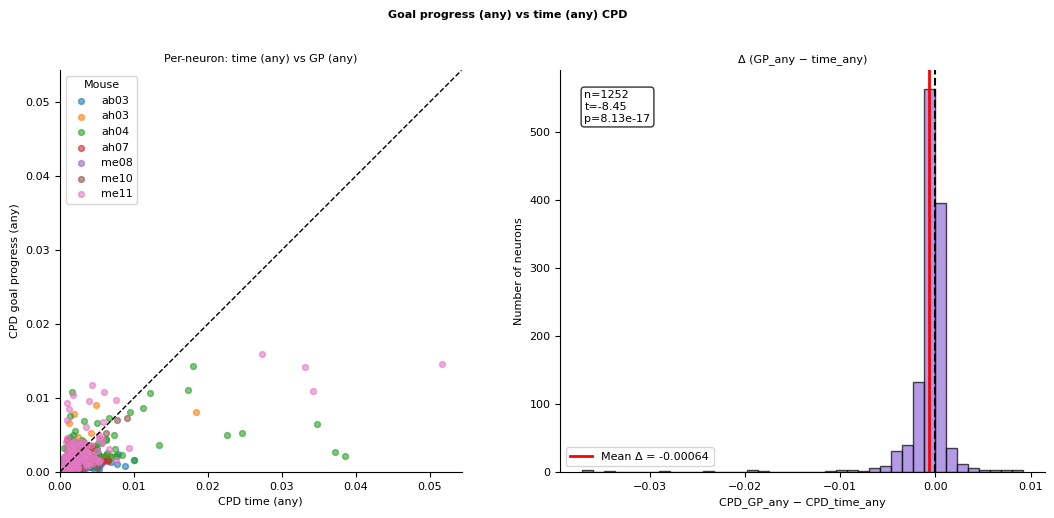

Per-mouse mean Δ (CPD_GP_any − CPD_time_any):
  ab03: μ=-0.00111  n=197
  ah03: μ=-0.00020  n=31
  ah04: μ=-0.00068  n=481
  ah07: μ=-0.00049  n=249
  me08: μ=-0.00027  n=78
  me10: μ=-0.00037  n=55
  me11: μ=-0.00052  n=161


In [52]:
# Per-neuron CPD: time (any) vs goal_progress (any).
# Uses max(time_from, time_to) and max(goal_progress, goal_progress_distance)
# as a per-neuron "any" CPD. (For rigorous joint CPDs you'd refit with
# joint_drop_groups=[('time_any',[...]),('gp_any',['goal_progress','goal_progress_distance'])].)
t_any, gp_any, mouse_tag = [], [], []
for mr, neuron_dict in CPD_results_gpdist.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        tf = cpd.get('time_from_reward', np.nan)
        tt_ = cpd.get('time_to_reward',   np.nan)
        gp  = cpd.get('goal_progress',           np.nan)
        gpd = cpd.get('goal_progress_distance',  np.nan)
        t_val  = np.nanmax([tf, tt_])
        gp_val = np.nanmax([gp, gpd])
        if np.isfinite(t_val) and np.isfinite(gp_val):
            t_any.append(t_val); gp_any.append(gp_val); mouse_tag.append(mouse)
t_any  = np.array(t_any);  gp_any = np.array(gp_any); mouse_tag = np.array(mouse_tag)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
for i, mouse in enumerate(sorted(np.unique(mouse_tag))):
    msk = mouse_tag == mouse
    ax.scatter(t_any[msk], gp_any[msk], alpha=0.6, s=18,
               color=plt.get_cmap('tab10')(i % 10), label=mouse)
lim = max(0.001, max(t_any.max(), gp_any.max()) * 1.05)
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
ax.set_xlabel('CPD time (any)')
ax.set_ylabel('CPD goal progress (any)')
ax.set_title('Per-neuron: time (any) vs GP (any)')
ax.legend(fontsize=8, title='Mouse')

ax = axes[1]
d = gp_any - t_any
ax.hist(d, bins=40, color='mediumpurple', alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(d.mean(), color='red', lw=2, label=f'Mean Δ = {d.mean():+.5f}')
tval, pval = st.ttest_1samp(d, 0)
ax.text(0.05, 0.95, f'n={len(d)}\nt={tval:.2f}\np={pval:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('CPD_GP_any − CPD_time_any')
ax.set_ylabel('Number of neurons')
ax.set_title('Δ (GP_any − time_any)')
ax.legend()
plt.suptitle('Goal progress (any) vs time (any) CPD',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Per-mouse paired test
from collections import defaultdict
by_mouse_diff = defaultdict(list)
for mr, neuron_dict in CPD_results_gpdist.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        tf = cpd.get('time_from_reward', np.nan)
        tt_ = cpd.get('time_to_reward',   np.nan)
        gp  = cpd.get('goal_progress',           np.nan)
        gpd = cpd.get('goal_progress_distance',  np.nan)
        t_val  = np.nanmax([tf, tt_])
        gp_val = np.nanmax([gp, gpd])
        if np.isfinite(t_val) and np.isfinite(gp_val):
            by_mouse_diff[mouse].append(gp_val - t_val)
print('Per-mouse mean Δ (CPD_GP_any − CPD_time_any):')
for mouse in sorted(by_mouse_diff.keys()):
    diffs = np.array(by_mouse_diff[mouse])
    print(f'  {mouse}: μ={diffs.mean():+.5f}  n={len(diffs)}')


In [ ]:

PFC_GP_DIST = ['place', 'goal_progress', 'speed', 'acceleration', 'time_since_reward', 'time_to_reward', 'distance_since_reward', 'distance_to_reward', 'goal_progress_distance']

GLM_results_gpdist, Permutation_results_gpdist, CPD_results_gpdist = run_or_load_glm(
    mouse_recdays, data_dic, SAVE_DIR, 'distance_gp',
    compute_cpd=True,
    regressors_to_include=PFC_GP_DIST,
    joint_drop_groups=[
        ('time_any', ['time_since_reward', 'time_to_reward']),
        ('gp_any',   ['goal_progress',     'goal_progress_distance']),
    ],
)


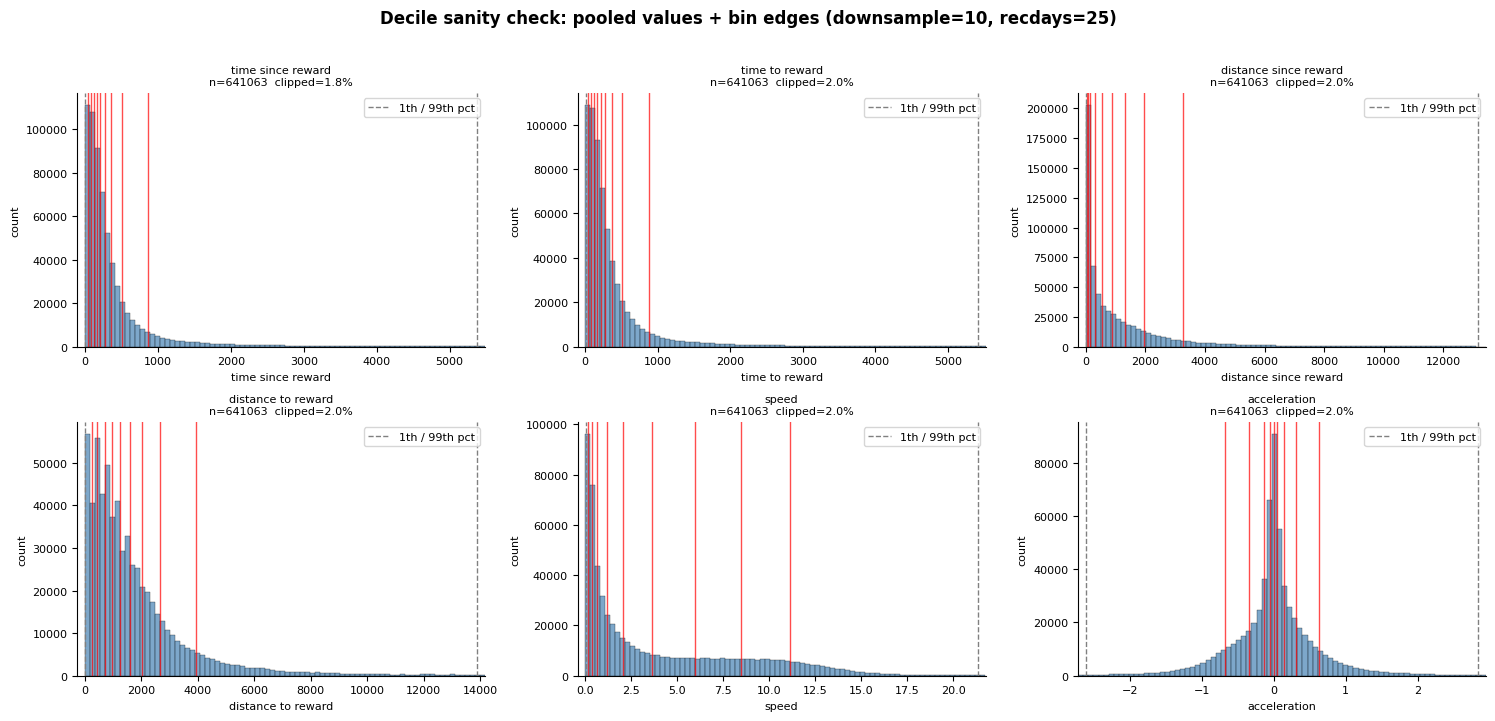

save_section('decile_check'): wrote 1 file(s) to ../glm_outputs/PFC


['../glm_outputs/PFC/decile_check__pooled.pkl']

In [57]:
from glm_analysis_v2 import plot_decile_distributions
pooled = plot_decile_distributions(mouse_recdays, data_dic)

save_section('decile_check', SAVE_DIR,
             results={'pooled': pooled},
             fig_names=['decile_dists'])
